In [151]:
import os
import re
import gc
import ast
import html
import glob
import shutil
import zipfile
import tarfile
import random
from time import time
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import hamming_loss, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import StratifiedKFold

try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
except ImportError:
    !pip install -q iterative-stratification
    from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sentence_transformers import SentenceTransformer

try:
    import emoji
except ImportError:
    !pip install -q emoji
    import emoji

from tqdm.notebook import tqdm
from IPython.display import display, Markdown

In [16]:
seed = 322

def set_seed(seed=322):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(seed)

print("Seed зафиксирован:", seed)

Seed зафиксирован: 322


In [17]:
def set_torch_seed(seed=322):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_torch_seed(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"

In [18]:
def read_csv_auto(path):
    path = Path(path)

    for sep in ["\t", ",", ";"]:
        try:
            data = pd.read_csv(path, sep=sep)

            if data.shape[1] >= 2:
                print(f"Файл {path} прочитан с sep={repr(sep)}, shape={data.shape}")
                return data

        except Exception:
            pass

    data = pd.read_csv(path)
    print(f"Файл {path} прочитан стандартно, shape={data.shape}")
    return data

In [19]:
def load_competition_data():
    
    search_roots = [Path("...")]

    if Path("/kaggle/input").exists():
        search_roots.append(Path("/kaggle/input"))

    extracted_root = Path("./extracted_data")
    extracted_root.mkdir(parents=True, exist_ok=True)

    archive_paths = []

    for root in search_roots:
        if root.exists():
            for path in root.rglob("*"):
                path_str = str(path).lower()
                if (
                    path.is_file()
                    and (
                        path_str.endswith(".zip")
                        or path_str.endswith(".tar")
                        or path_str.endswith(".tar.gz")
                        or path_str.endswith(".tgz")
                    )
                ):
                    archive_paths.append(path)

    for archive_path in archive_paths:
        archive_name = archive_path.name
        safe_archive_name = (
            archive_name
            .replace(".tar.gz", "")
            .replace(".tgz", "")
            .replace(".zip", "")
            .replace(".tar", "")
        )

        archive_extract_dir = extracted_root / safe_archive_name

        already_extracted = (
            archive_extract_dir.exists()
            and len(list(archive_extract_dir.rglob("*"))) > 0
        )

        if already_extracted:
            print(f"Архив уже распакован: {archive_path} -> {archive_extract_dir}")
            continue

        archive_extract_dir.mkdir(parents=True, exist_ok=True)

        print(f"Распаковываю архив: {archive_path} -> {archive_extract_dir}")

        if str(archive_path).lower().endswith(".zip"):
            with zipfile.ZipFile(archive_path, "r") as archive:
                archive.extractall(archive_extract_dir)

        elif (
            str(archive_path).lower().endswith(".tar")
            or str(archive_path).lower().endswith(".tar.gz")
            or str(archive_path).lower().endswith(".tgz")
        ):
            with tarfile.open(archive_path, "r:*") as archive:
                archive.extractall(archive_extract_dir)

        else:
            raise ValueError(f"Неизвестный формат архива: {archive_path}")

    search_roots.append(extracted_root)

    all_csv_files = []

    for root in search_roots:
        if root.exists():
            all_csv_files.extend(list(root.rglob("*.csv")))

    all_csv_files = sorted(set(all_csv_files))

    print("Найденные CSV-файлы:")
    for file in all_csv_files:
        print(file)

    if len(all_csv_files) == 0:
        print("\nТекущая папка:", Path(".").resolve())
        print("Файлы в текущей папке:")
        for item in Path(".").iterdir():
            print(item)

        if Path("/kaggle/input").exists():
            print("\nПапки в /kaggle/input:")
            for item in Path("/kaggle/input").iterdir():
                print(item)

        raise FileNotFoundError("CSV-файлы не найдены")

    def find_file_by_name(possible_names):
        possible_names = [name.lower() for name in possible_names]

        # 1. Точное совпадение имени файла
        for file in all_csv_files:
            if file.name.lower() in possible_names:
                return file

        # 2. Частичное совпадение
        for file in all_csv_files:
            file_name = file.name.lower()
            for name in possible_names:
                name_without_csv = name.replace(".csv", "")
                if name_without_csv in file_name:
                    return file

        return None

    train_path = find_file_by_name(["train.csv"])
    test_path = find_file_by_name(["test.csv"])
    sample_submission_path = find_file_by_name([
        "sample_submission.csv",
        "sample.csv",
        "submission.csv"
    ])

    if train_path is None:
        raise FileNotFoundError(
            "Не найден train.csv. Найденные CSV: "
            + str([str(path) for path in all_csv_files])
        )

    if test_path is None:
        raise FileNotFoundError(
            "Не найден test.csv. Найденные CSV: "
            + str([str(path) for path in all_csv_files])
        )

    if sample_submission_path is None:
        raise FileNotFoundError(
            "Не найден sample_submission.csv. Найденные CSV: "
            + str([str(path) for path in all_csv_files])
        )

    print("\nИспользуем файлы:")
    print("train:", train_path)
    print("test:", test_path)
    print("sample_submission:", sample_submission_path)

    train_data = read_csv_auto(train_path)
    test_data = read_csv_auto(test_path)
    sample_submission = read_csv_auto(sample_submission_path)

    print("\nИтоговые размеры:")
    print("train_data:", train_data.shape)
    print("test_data:", test_data.shape)
    print("sample_submission:", sample_submission.shape)

    display(train_data.head())
    display(test_data.head())
    display(sample_submission.head())

    return (
        train_data,
        test_data,
        sample_submission,
        train_path,
        test_path,
        sample_submission_path
    )


train_data, test_data, sample_submission, train_path, test_path, sample_submission_path = load_competition_data()

Найденные CSV-файлы:
/kaggle/input/datasets/olllllllll/nlpnlp/sample_submission.csv
/kaggle/input/datasets/olllllllll/nlpnlp/test.csv
/kaggle/input/datasets/olllllllll/nlpnlp/train.csv

Используем файлы:
train: /kaggle/input/datasets/olllllllll/nlpnlp/train.csv
test: /kaggle/input/datasets/olllllllll/nlpnlp/test.csv
sample_submission: /kaggle/input/datasets/olllllllll/nlpnlp/sample_submission.csv
Файл /kaggle/input/datasets/olllllllll/nlpnlp/train.csv прочитан с sep='\t', shape=(16701, 6)
Файл /kaggle/input/datasets/olllllllll/nlpnlp/test.csv прочитан с sep='\t', shape=(4969, 5)
Файл /kaggle/input/datasets/olllllllll/nlpnlp/sample_submission.csv прочитан с sep=',', shape=(4969, 2)

Итоговые размеры:
train_data: (16701, 6)
test_data: (4969, 5)
sample_submission: (4969, 2)


,id,source,title,text,publication_date,target
0,0,Novosti,Рейтинг регионов по уровню закредитованности н...,Средний <content>уровень</content> <source>ria...,2019-12-23 00:00,"[0, 1, 0, 0, 0]"
1,1,Novosti,Названы самые закредитованные российские регионы,"МОСКВА, 23 дек — РИА Новости. Наиболее закре...",2019-12-23 00:21,"[0, 1, 0, 0, 0]"
2,2,Novosti,В России пройдут учения по обеспечению устойчи...,"МОСКВА, 23 дек - РИА Новости. Всероссийские у...",2019-12-23 00:28,"[1, 0, 0, 1, 0]"
3,3,Novosti,Самолеты НАТО стали чаще летать у границ Росси...,"МОСКВА, 23 дек - РИА 📄 Новости. <hr> 📝 Интенс...",2019-12-23 00:39,"[1, 0, 0, 0, 0]"
4,4,Novosti,Сюткин оценил шутку Шнурова над обидевшим Гага...,"МОСКВА, &nbsp;23 дек — РИА </content> Новости....",2019-12-23 00:50,"[0, 0, 0, 0, 0]"


,id,source,title,text,publication_date
0,16701,Spletnesti,Дым от австралийс...,...,2020-01-01 07:35
1,16702,Spletnesti,Во Владивостоке в...,...,2020-01-01 08:22
2,16703,Spletnesti,Папа римский шлёп...,...,2020-01-01 15:37
3,16704,Spletnesti,Около 200 жителей...,...,2020-01-01 15:56
4,16705,Zholtosti,Как провести новогодние каникулы с ребенком по...,🎊 Посмотреть на фейерверки с точки зрения нау...,2020-01-02 08:09


,id,target
0,16701,"[0,0,0,0,0]"
1,16702,"[0,0,0,0,0]"
2,16703,"[0,0,0,0,0]"
3,16704,"[0,0,0,0,0]"
4,16705,"[0,0,0,0,0]"


## Анализ данных

In [20]:
print("Колонки train:")
print(train_data.columns.tolist())

print("\nКолонки test:")
print(test_data.columns.tolist())

print("\nКолонки sample_submission:")
print(sample_submission.columns.tolist())

Колонки train:
['id', 'source', 'title', 'text', 'publication_date', 'target']

Колонки test:
['id', 'source', 'title', 'text', 'publication_date']

Колонки sample_submission:
['id', 'target']


In [21]:
display(train_data.head())
display(test_data.head())

,id,source,title,text,publication_date,target
0,0,Novosti,Рейтинг регионов по уровню закредитованности н...,Средний <content>уровень</content> <source>ria...,2019-12-23 00:00,"[0, 1, 0, 0, 0]"
1,1,Novosti,Названы самые закредитованные российские регионы,"МОСКВА, 23 дек — РИА Новости. Наиболее закре...",2019-12-23 00:21,"[0, 1, 0, 0, 0]"
2,2,Novosti,В России пройдут учения по обеспечению устойчи...,"МОСКВА, 23 дек - РИА Новости. Всероссийские у...",2019-12-23 00:28,"[1, 0, 0, 1, 0]"
3,3,Novosti,Самолеты НАТО стали чаще летать у границ Росси...,"МОСКВА, 23 дек - РИА 📄 Новости. <hr> 📝 Интенс...",2019-12-23 00:39,"[1, 0, 0, 0, 0]"
4,4,Novosti,Сюткин оценил шутку Шнурова над обидевшим Гага...,"МОСКВА, &nbsp;23 дек — РИА </content> Новости....",2019-12-23 00:50,"[0, 0, 0, 0, 0]"


,id,source,title,text,publication_date
0,16701,Spletnesti,Дым от австралийс...,...,2020-01-01 07:35
1,16702,Spletnesti,Во Владивостоке в...,...,2020-01-01 08:22
2,16703,Spletnesti,Папа римский шлёп...,...,2020-01-01 15:37
3,16704,Spletnesti,Около 200 жителей...,...,2020-01-01 15:56
4,16705,Zholtosti,Как провести новогодние каникулы с ребенком по...,🎊 Посмотреть на фейерверки с точки зрения нау...,2020-01-02 08:09


В данных есть несколько всмопогательных колонок типа `id`, `source`, `title`, `publication_date`. Основной текст новости находится в колонке `text`, а заголовок в колонке `title`. Целевая переменная находится в колонке `target`.  Но так как задача мультилейбл-классификации, в этой колонке хранится набор бинарных меток для каждого объекта, может быть лучше разделить эту колонку на несколько

In [22]:
id_column = "id"
title_column = "title"
text_column = "text"
target_column = "target"
source_column = "source"
date_column = "publication_date"

Перед анализом меток нужно понять, в каком формате хранится колонка `target`. На первый взгляд она похожа на список из нулей и единиц, но после чтения из csv такие значения часто становятся строками. Поэтому проверим типы значений и несколько примеров

In [23]:
print("Тип первого значения target:", type(train_data[target_column].iloc[0]))

print("\nПервые 10 значений target:")
for value in train_data[target_column].head(10):
    print(value)

Тип первого значения target: <class 'str'>

Первые 10 значений target:
[0, 1, 0, 0, 0]
[0, 1, 0, 0, 0]
[1, 0, 0, 1, 0]
[1, 0, 0, 0, 0]
[0, 0, 0, 0, 0]
[1, 0, 0, 0, 0]
[0, 0, 0, 0, 0]
[1, 0, 0, 0, 0]
[1, 1, 0, 0, 0]
[0, 0, 0, 0, 0]


Колонка `target` хранит целевую переменную в виде строки, которая похожа на список из пяти нулей и единиц. Для анализа данных и обучения моделей удобнее преобразовать эту колонку в пять отдельных бинарных колонок

In [24]:
def parse_target(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    return value

target_lists = train_data[target_column].apply(parse_target)

number_of_classes = len(target_lists.iloc[0])
target_columns = [f"target_{i}" for i in range(number_of_classes)]

target_data = pd.DataFrame(
    target_lists.tolist(),
    columns=target_columns,
    index=train_data.index
)

train_data = pd.concat([train_data, target_data], axis=1)

print("Количество классов:", number_of_classes)
print("Названия новых target-колонок:", target_columns)

display(train_data[[target_column] + target_columns].head())

Количество классов: 5
Названия новых target-колонок: ['target_0', 'target_1', 'target_2', 'target_3', 'target_4']


,target,target_0,target_1,target_2,target_3,target_4
0,"[0, 1, 0, 0, 0]",0,1,0,0,0
1,"[0, 1, 0, 0, 0]",0,1,0,0,0
2,"[1, 0, 0, 1, 0]",1,0,0,1,0
3,"[1, 0, 0, 0, 0]",1,0,0,0,0
4,"[0, 0, 0, 0, 0]",0,0,0,0,0


Окей, теперь еще перед обучением моделей нужно проверить, есть ли в данных пропущенные значения. Для нашей текстовой задачи особенно важны пропуски в колонках `title` и `text`, потому что именно эти поля будут использоваться для построения признаков

In [25]:
print("Пропуски в train:")
display(train_data.isna().sum())

print("Пропуски в test:")
display(test_data.isna().sum())

Пропуски в train:


id                  0
source              0
title               0
text                0
publication_date    0
target              0
target_0            0
target_1            0
target_2            0
target_3            0
target_4            0
dtype: int64

Пропуски в test:


id                  0
source              0
title               0
text                0
publication_date    0
dtype: int64

Отлично, пропусков у нас вообще нет, ничего заполнять не нужно, теперь проверим дубликаты значит 

In [26]:
train_full_duplicates = train_data.duplicated().sum()
test_full_duplicates = test_data.duplicated().sum()

print("Полные дубликаты строк в train:", train_full_duplicates)
print("Полные дубликаты строк в test:", test_full_duplicates)

Полные дубликаты строк в train: 0
Полные дубликаты строк в test: 0


Да, полных дублей у нас нет ни в тесте, ни в трейне, но для текстовой классификации особенно важно проверить дубликаты по тексту. Потому что даже если строки имеют разные `id`, одинаковый текст может повторяться в данных

In [27]:
train_text_duplicates = train_data[text_column].duplicated().sum()
test_text_duplicates = test_data[text_column].duplicated().sum()

print("Дубликаты по колонке text в train:", train_text_duplicates)
print("Дубликаты по колонке text в test:", test_text_duplicates)

Дубликаты по колонке text в train: 0
Дубликаты по колонке text в test: 3


In [28]:
train_text_set = set(train_data[text_column].astype(str))
test_text_set = set(test_data[text_column].astype(str))

common_texts = train_text_set.intersection(test_text_set)

print("Количество одинаковых текстов в train и test:", len(common_texts))
print("Доля таких текстов в test:", len(common_texts) / len(test_data))

Количество одинаковых текстов в train и test: 0
Доля таких текстов в test: 0.0


В трейне не найдено дубликатов ни по колонке `text`, ни по паре `title` + `text`. Это хорошо для нас для дальнейшего обучения и валидации, так как одинаковые тексты не будут попадать одновременно в обучающую и валидационную части

А вот в тестовой выборке найдено 3 дубликата по колонке `text`, также 3 дубликата по паре `title` + `text`. Удалять эти строки нельзя, потому что итоговый файл сабмита должен содержать предсказание для каждого `id` из тестовой выборки

Пересечений одинаковых текстов между train и test нет, то есть в тестовой выборке нет объектов, для которых можно было бы напрямую перенести известную метку из обучающей выборки

Теперь посмотрим, насколько часто встречается каждый из пяти классов. У нас мультилейбл-классификация, а это для нее особенно важно, потому что классы могут быть несбалансированными, и одни метки могут встречаться часто, а другие значительно реже

In [29]:
class_counts = train_data[target_columns].sum()
class_shares = train_data[target_columns].mean()

class_distribution = pd.DataFrame({
    "количество объектов": class_counts,
    "доля объектов": class_shares
})

display(class_distribution)

,количество объектов,доля объектов
target_0,7145,0.427819
target_1,2276,0.136279
target_2,1836,0.109934
target_3,1243,0.074427
target_4,544,0.032573


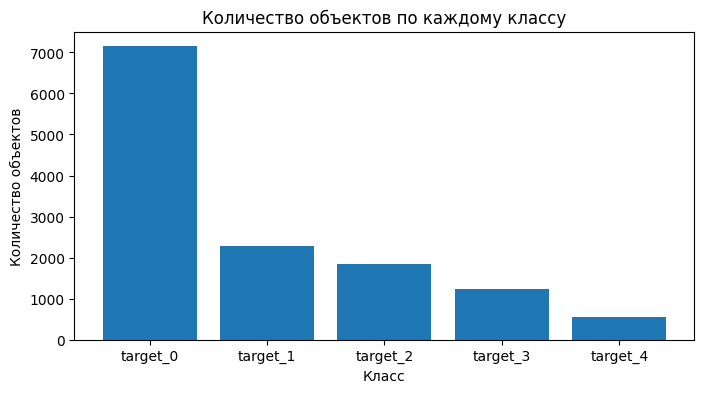

In [30]:
plt.figure(figsize=(8, 4))
plt.bar(class_distribution.index, class_distribution["количество объектов"])

plt.title("Количество объектов по каждому классу")
plt.xlabel("Класс")
plt.ylabel("Количество объектов")
plt.xticks(rotation=0)

plt.show()

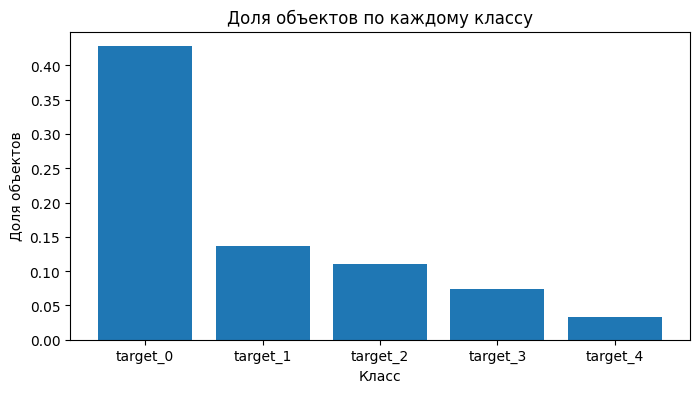

In [31]:
plt.figure(figsize=(8, 4))
plt.bar(class_distribution.index, class_distribution["доля объектов"])

plt.title("Доля объектов по каждому классу")
plt.xlabel("Класс")
plt.ylabel("Доля объектов")
plt.xticks(rotation=0)

plt.show()

Вот тут уже можно сделать важный вывод. Распределение целевых классов у нас оказалось несбалансированным. Чаще всего встречается класс target_0, он присутствует примерно у 42.8% объектов трейна, самым редким является класс target_4, его доля составляет только около 3.3%

Такой дисбаланс важен для дальнейшего построения моделей наших. Во-первых, при разбиении данных на обучение и валидацию нужно сохранить распределение меток, поэтому далее видимо будет использоваться multilabel-stratified split. Во-вторых, для финальных предсказаний не стоит автоматически использовать единый порог 0.5 для всех классов. Редкие и частые классы могут требовать разных threshold, поэтому на этапе постпроцессинга будет выполняться подбор индивидуальных порогов для каждого класса отдельно уже

Так как задача мультилейбл-классификации, одному тексту может соответствовать сразу несколько классов. Посмотрим, сколько положительных меток обычно имеет один объект

In [32]:
train_data["label_count"] = train_data[target_columns].sum(axis=1)
label_count_distribution = train_data["label_count"].value_counts().sort_index()
display(label_count_distribution)

label_count
0    5643
1    9209
2    1714
3     133
4       2
Name: count, dtype: int64

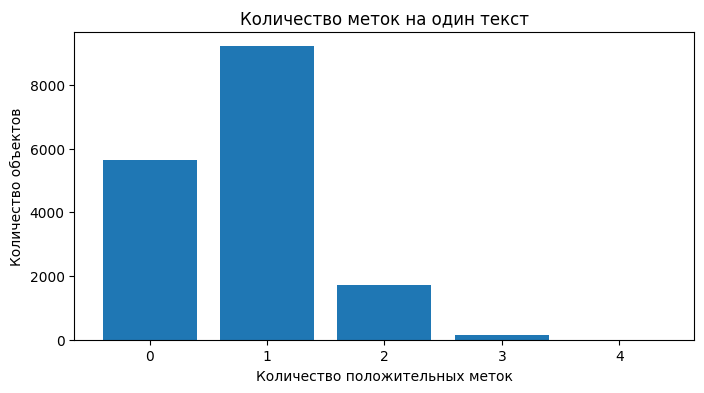

In [33]:
plt.figure(figsize=(8, 4))
plt.bar(label_count_distribution.index.astype(str), label_count_distribution.values)

plt.title("Количество меток на один текст")
plt.xlabel("Количество положительных меток")
plt.ylabel("Количество объектов")

plt.show()

In [34]:
print("Среднее количество меток на объект:", train_data["label_count"].mean())
print("Медианное количество меток на объект:", train_data["label_count"].median())
print("Минимальное количество меток:", train_data["label_count"].min())
print("Максимальное количество меток:", train_data["label_count"].max())

Среднее количество меток на объект: 0.781031075983474
Медианное количество меток на объект: 1.0
Минимальное количество меток: 0
Максимальное количество меток: 4


In [35]:
zero_label_count = (train_data["label_count"] == 0).sum()
zero_label_share = zero_label_count / len(train_data)

print("Количество объектов без положительных меток:", zero_label_count)
print("Доля объектов без положительных меток:", zero_label_share)

Количество объектов без положительных меток: 5643
Доля объектов без положительных меток: 0.3378839590443686


Тоже важный вывод, большинство объектов имеет одну положительную метку, таких объектов 9209. При этом 5643 объекта, то есть около 33.8% трейна не имеют ни одной положительной метки. Это означает, что комбинация [0, 0, 0, 0, 0] является допустимой и достаточно частой

Среднее количество положительных меток на один объект составляет примерно 0.78, медианное значение равно 1. Объекты с тремя и четырьмя метками встречаются редко, а объектов со всеми пятью положительными метками в обучающей выборке нет

Этот результат пригодится для постпроцессинга. Так как объекты без положительных меток часто встречаются в данных, не следует автоматически заставлять модель предсказывать хотя бы один класс для каждого текста, вместо этого лучше подбирать индивидуальные пороги для каждого класса на валидации

Возникла мысль смотреть не только на частоту отдельных классов, но и на их сочетания. Некоторые классы могут часто встречаться вместе, а некоторые комбинации могут быть редкими

In [36]:
label_combinations = (
    train_data[target_columns]
    .astype(str)
    .agg("".join, axis=1)
    .value_counts()
)

display(label_combinations.head(20))
print("Количество уникальных сочетаний меток:", label_combinations.shape[0])

10000    5766
00000    5643
00100    1455
01000    1169
11000     689
00010     516
00001     303
10010     301
01010     246
10100     171
10001      95
11010      90
00101      90
00110      60
01100      28
01001      23
11100      13
00011      11
11001       9
01110       5
Name: count, dtype: int64

Количество уникальных сочетаний меток: 28


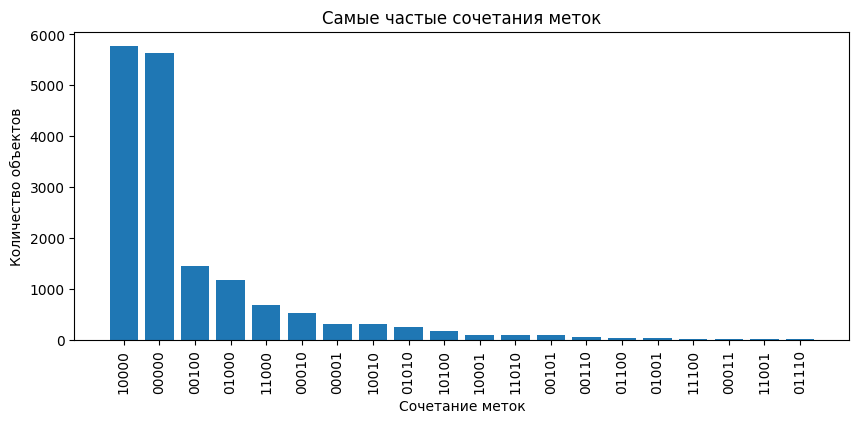

In [37]:
plt.figure(figsize=(10, 4))
plt.bar(label_combinations.head(20).index, label_combinations.head(20).values)

plt.title("Самые частые сочетания меток")
plt.xlabel("Сочетание меток")
plt.ylabel("Количество объектов")
plt.xticks(rotation=90)

plt.show()

Самые частые сочетания меток это 10000 и 00000. Комбинация 10000 у нас означает, что объект относится только к классу target_0, а 00000 означает отсутствие положительных меток вообще. Также встречаются одиночные классы 00100, 01000, 00010, 00001, но их частоты заметно ниже. Сочетания нескольких положительных меток есть, однако они встречаются значительно реже, чем объекты с одной меткой или без меток

В целом опять приходим к выводу, что для дальнейшего обучения важно использовать корректное разбиение на train и validation, которое будет учитывать такое несбалансированное распределение. Также при формировании итоговых предсказаний не стоит искусственно добавлять положительную метку каждому объекту, так как комбинация 00000 является частой

Теперь проанализируем длину заголовков и основных текстов

In [38]:
train_data["title_length"] = train_data[title_column].astype(str).apply(len)
test_data["title_length"] = test_data[title_column].astype(str).apply(len)

train_data["text_length"] = train_data[text_column].astype(str).apply(len)
test_data["text_length"] = test_data[text_column].astype(str).apply(len)

train_data["title_word_count"] = train_data[title_column].astype(str).apply(lambda text: len(text.split()))
test_data["title_word_count"] = test_data[title_column].astype(str).apply(lambda text: len(text.split()))

train_data["text_word_count"] = train_data[text_column].astype(str).apply(lambda text: len(text.split()))
test_data["text_word_count"] = test_data[text_column].astype(str).apply(lambda text: len(text.split()))

In [39]:
length_statistics = pd.DataFrame({
    "train_title_symbols": train_data["title_length"].describe(),
    "test_title_symbols": test_data["title_length"].describe(),
    "train_text_symbols": train_data["text_length"].describe(),
    "test_text_symbols": test_data["text_length"].describe(),
    "train_title_words": train_data["title_word_count"].describe(),
    "test_title_words": test_data["title_word_count"].describe(),
    "train_text_words": train_data["text_word_count"].describe(),
    "test_text_words": test_data["text_word_count"].describe(),
})

display(length_statistics)

,train_title_symbols,test_title_symbols,train_text_symbols,test_text_symbols,train_title_words,test_title_words,train_text_words,test_text_words
count,16701.000000,4969.000000,16701.000000,4969.000000,16701.000000,4969.000000,16701.000000,4969.000000
mean,60.208311,78.087342,2062.794204,2612.078285,8.391653,10.100423,268.385306,287.809217
std,10.455982,29.719800,1361.683745,3342.553565,1.792419,3.729773,183.882501,450.857364
min,10.000000,14.000000,349.000000,37.000000,2.000000,1.000000,43.000000,5.000000
25%,54.000000,58.000000,1370.000000,850.000000,7.000000,8.000000,176.000000,113.000000
50%,63.000000,69.000000,1762.000000,1357.000000,8.000000,9.000000,226.000000,169.000000
75%,68.000000,99.000000,2293.000000,3438.000000,10.000000,12.000000,298.000000,259.000000
max,82.000000,183.000000,26239.000000,47361.000000,14.000000,31.000000,3873.000000,7587.000000


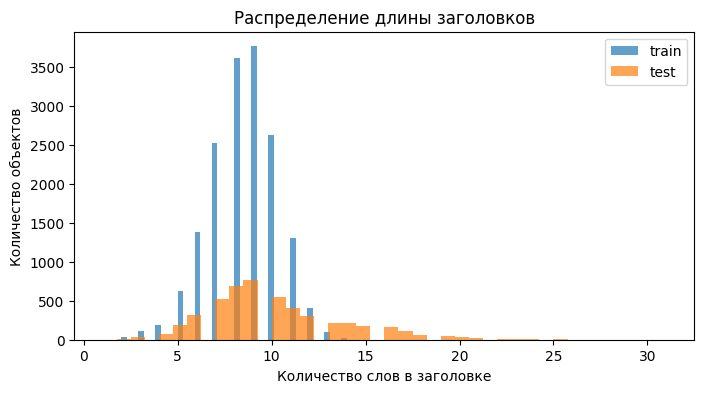

In [40]:
plt.figure(figsize=(8, 4))

plt.hist(train_data["title_word_count"], bins=40, alpha=0.7, label="train")
plt.hist(test_data["title_word_count"], bins=40, alpha=0.7, label="test")

plt.title("Распределение длины заголовков")
plt.xlabel("Количество слов в заголовке")
plt.ylabel("Количество объектов")
plt.legend()

plt.show()

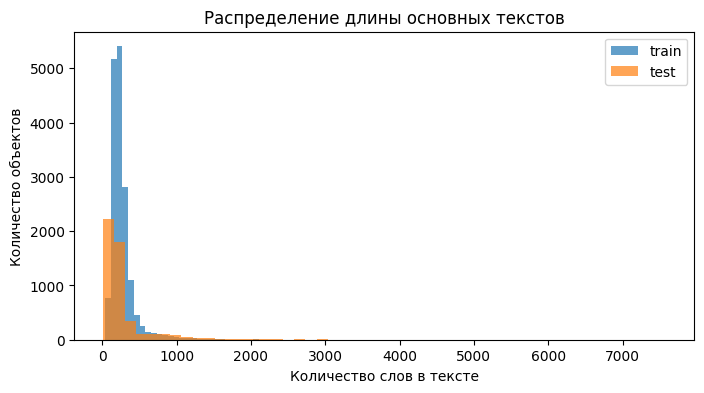

In [41]:
plt.figure(figsize=(8, 4))

plt.hist(train_data["text_word_count"], bins=50, alpha=0.7, label="train")
plt.hist(test_data["text_word_count"], bins=50, alpha=0.7, label="test")

plt.title("Распределение длины основных текстов")
plt.xlabel("Количество слов в тексте")
plt.ylabel("Количество объектов")
plt.legend()

plt.show()

In [42]:
quantiles = [0.5, 0.75, 0.9, 0.95, 0.99]

text_length_quantiles = pd.DataFrame({
    "train_text_words": train_data["text_word_count"].quantile(quantiles),
    "test_text_words": test_data["text_word_count"].quantile(quantiles),
    "train_title_words": train_data["title_word_count"].quantile(quantiles),
    "test_title_words": test_data["title_word_count"].quantile(quantiles),
})

display(text_length_quantiles)

,train_text_words,test_text_words,train_title_words,test_title_words
0.50,226.0,169.00,8.0,9.0
0.75,298.0,259.00,10.0,12.0
0.90,403.0,613.40,11.0,15.0
0.95,548.0,999.60,11.0,17.0
0.99,1092.0,2057.96,12.0,21.0


Заголовки в трейне в среднем содержат около 8 слов, а в тестовой около 10 слов. Основные тексты в среднем содержат около 268 слов в трейне и около 288 слов в тесте.

Распределения длины текстов имеют длинный правый хвост: большинство текстов относительно короткие, но встречаются отдельные очень длинные новости. Максимальная длина основного текста достигает 3873 слов в трейне и 7587 слов в тесте.

Для например модели на основе трансформера это важно, потому что вход модели имеет ограничение по максимальной длине последовательности. Поэтому на этапе обучения нужно будет выбрать разумное значение масимальной длины и учитывать, что часть длинных текстов будет обрезаться

В данных есть две текстовые колонки: `title` и `text`. У нас многие модели принимают 1 сроку текста на 1 объект, поэтому для дальнейшего удобства объединим заголовок и текст в одну колонку

In [43]:
train_data["full_text"] = (
    train_data[title_column].astype(str)
    + " "
    + train_data[text_column].astype(str)
)

test_data["full_text"] = (
    test_data[title_column].astype(str)
    + " "
    + test_data[text_column].astype(str)
)

model_text_column = "full_text"

display(train_data[[title_column, text_column, model_text_column]].head(3))

,title,text,full_text
0,Рейтинг регионов по уровню закредитованности н...,Средний <content>уровень</content> <source>ria...,Рейтинг регионов по уровню закредитованности н...
1,Названы самые закредитованные российские регионы,"МОСКВА, 23 дек — РИА Новости. Наиболее закре...",Названы самые закредитованные российские регио...
2,В России пройдут учения по обеспечению устойчи...,"МОСКВА, 23 дек - РИА Новости. Всероссийские у...",В России пройдут учения по обеспечению устойчи...


В данных также есть колонка `source`, которая показывает источник новости. Посмотрим, какие источники встречаются в обучающей и тестовой выборках и насколько отличаются их распределения

In [44]:
train_source_counts = train_data[source_column].value_counts()
test_source_counts = test_data[source_column].value_counts()

print("Источники в train:")
display(train_source_counts)

print("Источники в test:")
display(test_source_counts)

Источники в train:


source
Novosti      12759
Svezhesti     3942
Name: count, dtype: int64

Источники в test:


source
Novosti       1996
Zholtosti     1538
Spletnesti     867
Svezhesti      568
Name: count, dtype: int64

In [45]:
train_source_shares = train_data[source_column].value_counts(normalize=True)
test_source_shares = test_data[source_column].value_counts(normalize=True)

source_distribution = pd.DataFrame({
    "доля в train": train_source_shares,
    "доля в test": test_source_shares
}).fillna(0)

display(source_distribution)

,доля в train,доля в test
source,,
Novosti,0.763966,0.401690
Spletnesti,0.000000,0.174482
Svezhesti,0.236034,0.114309
Zholtosti,0.000000,0.309519


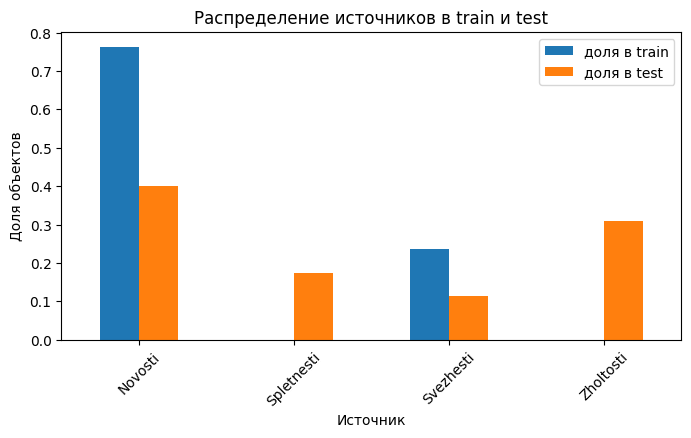

In [46]:
source_distribution.plot(kind="bar", figsize=(8, 4))

plt.title("Распределение источников в train и test")
plt.xlabel("Источник")
plt.ylabel("Доля объектов")
plt.xticks(rotation=45)
plt.legend()

plt.show()

In [47]:
source_target_distribution = (train_data.groupby(source_column)[target_columns].mean())

display(source_target_distribution)

,target_0,target_1,target_2,target_3,target_4
source,,,,,
Novosti,0.431382,0.136296,0.109413,0.080884,0.013794
Svezhesti,0.416286,0.136225,0.111618,0.053526,0.093354


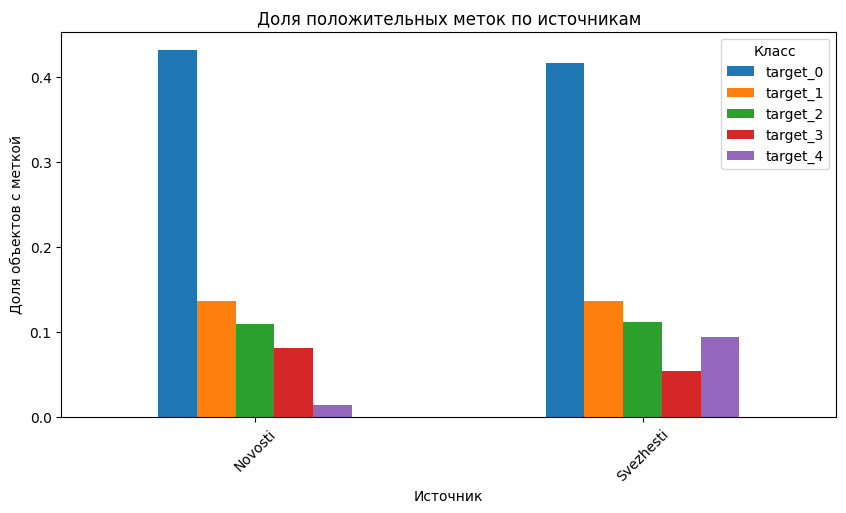

In [48]:
source_target_distribution.plot(kind="bar", figsize=(10, 5))

plt.title("Доля положительных меток по источникам")
plt.xlabel("Источник")
plt.ylabel("Доля объектов с меткой")
plt.xticks(rotation=45)
plt.legend(title="Класс")

plt.show()

Тоже интересная картина у нас тут. В обучающей выборке присутствуют только два источника Novosti и Svezhesti. При этом в тестовой выборке встречаются четыре источника кроме тех двух еще и Spletnesti и Zholtosti.

Причем распределение источников между трейном и тестом заметно отличается. В трейн большую часть объектов составляет источник Novosti, тогда как в тесте значительная доля приходится на источники Spletnesti и Zholtosti, которых вообще нет в обучающей выборке

То есть у нас сдвиг распределения между обучающей и тестовой выборками. Поэтому использовать `source` как отдельный категориальный признак нужно осторожно, у нас модель может переобучиться на источники, которые есть в трейне, но не сможет корректно обработать новые источники из теста

Также видно, что распределение классов по источникам в трейне немного отличается. Например, класс target_4 заметно чаще встречается у источника Svezhesti, чем у Novosti. Это может быть полезным наблюдением, но в основном лучше опираться наверное прежде всего на текст новости, а не на название источника

В данных еще есть колонка `publication_date`. Проверим временной период обучающей и тестовой выборок, чтобы понять, есть ли между ними еще и временной сдвиг

In [49]:
train_data[date_column] = pd.to_datetime(train_data[date_column])
test_data[date_column] = pd.to_datetime(test_data[date_column])

print("Минимальная дата в train:", train_data[date_column].min())
print("Максимальная дата в train:", train_data[date_column].max())

print("\nМинимальная дата в test:", test_data[date_column].min())
print("Максимальная дата в test:", test_data[date_column].max())

Минимальная дата в train: 2019-12-23 00:00:00
Максимальная дата в train: 2020-07-30 23:59:00

Минимальная дата в test: 2020-01-01 07:35:00
Максимальная дата в test: 2020-08-31 21:06:00


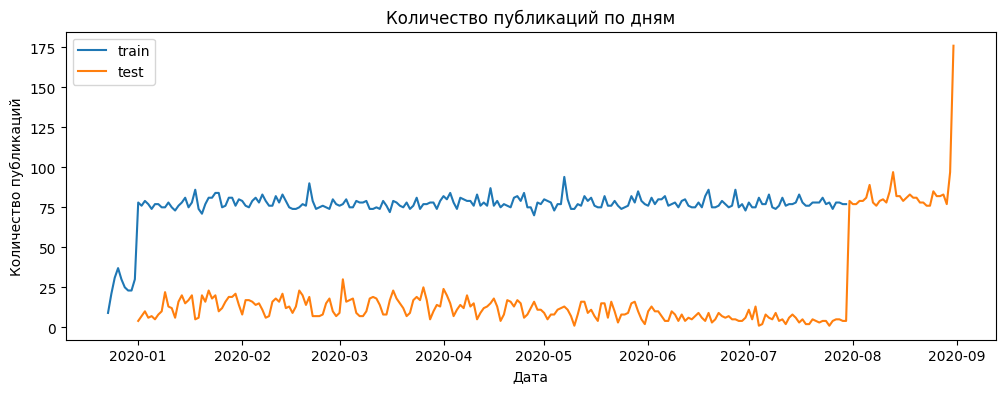

In [50]:
train_publications_by_day = (train_data.set_index(date_column).resample("D").size())

test_publications_by_day = (test_data.set_index(date_column).resample("D").size())

plt.figure(figsize=(12, 4))

plt.plot(train_publications_by_day.index, train_publications_by_day.values, label="train")
plt.plot(test_publications_by_day.index, test_publications_by_day.values, label="test")

plt.title("Количество публикаций по дням")
plt.xlabel("Дата")
plt.ylabel("Количество публикаций")
plt.legend()

plt.show()

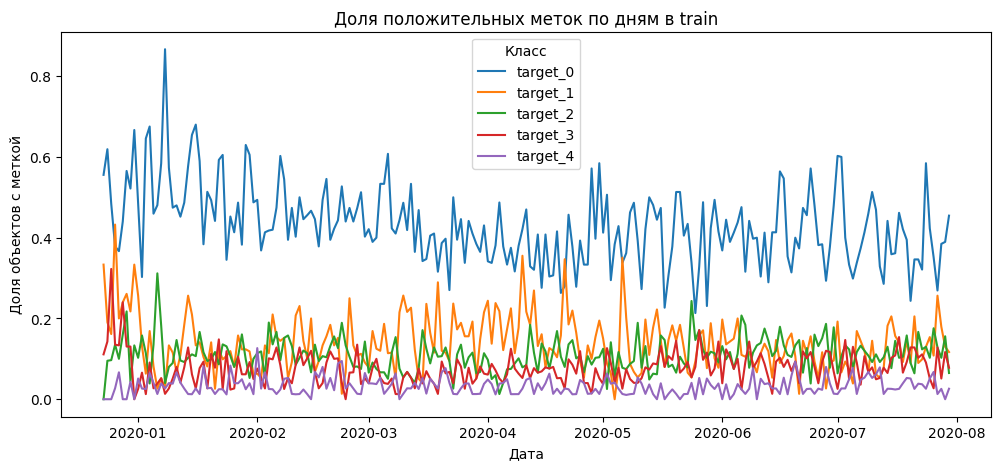

In [51]:
train_data["publication_date_day"] = train_data[date_column].dt.date

target_distribution_by_day = (
    train_data
    .groupby("publication_date_day")[target_columns]
    .mean()
)

target_distribution_by_day.plot(figsize=(12, 5))

plt.title("Доля положительных меток по дням в train")
plt.xlabel("Дата")
plt.ylabel("Доля объектов с меткой")
plt.legend(title="Класс")

plt.show()

Обучающая выборка охватывает период с 23 декабря 2019 года по 30 июля 2020 года. Тестовая выборка охватывает период с 1 января 2020 года по 31 августа 2020 года.

Периоды трейна и теста частично пересекаются, однако в тестовой выборке есть более поздний август 2020 года, которого нет в обучающей выборке. То есть у нас еще и временной сдвиг между трейном и тестом.

На графике количества публикаций по дням видно, что в train число публикаций после начала января держится примерно на стабильном уровне. В тесте распределение менее равномерное, у нас в августе заметно увеличивается число публикаций. Для модели это означает, что она должна быть устойчивой к небольшому изменению распределения данных во времени, поэтому основную ставку лучше делать на текстовые признаки, а не на дату публикации как прямой числовой признак

Ну теперь для качественного понимания задачи осталось посмотреть несколько примеров текстов для каждого класса. Это поможет понять, насколько классы отличаются по содержанию и есть ли в данных очевидные может быть какие-то тематические признаки

In [52]:
print(target_columns)
print(type(target_columns))

print("Дубли колонок:")
print(train_data.columns[train_data.columns.duplicated()].tolist())

for column in target_columns:
    print(column, type(train_data[column]), getattr(train_data[column], "shape", None))

['target_0', 'target_1', 'target_2', 'target_3', 'target_4']
<class 'list'>
Дубли колонок:
[]
target_0 <class 'pandas.core.series.Series'> (16701,)
target_1 <class 'pandas.core.series.Series'> (16701,)
target_2 <class 'pandas.core.series.Series'> (16701,)
target_3 <class 'pandas.core.series.Series'> (16701,)
target_4 <class 'pandas.core.series.Series'> (16701,)


In [53]:
for column in target_columns:
    print("=" * 100)
    print(f"Примеры для класса {column}")

    mask = train_data[column].astype(int).eq(1)

    examples = train_data.loc[mask].sample(
        n=min(3, int(mask.sum())),
        random_state=seed
    )

    for i, (_, row) in enumerate(examples.iterrows(), 1):
        print(f"\nПример {i}")
        print("Заголовок:", str(row[title_column]))
        print("Текст:", str(row[text_column])[:800])

        target_values = row[target_columns].astype(int).tolist()
        print("Target:", target_values)
        print()

Примеры для класса target_0

Пример 1
Заголовок: В Турции 15 тысяч человек получили временное жилье после землетрясения
Текст: АНКАРА, 26 янв – РИА Новости.  <ul> </span> &#160;Более 15 ❓ тысяч человек в восточных провинциях  Турции , </p> <strong> пострадавших от землетрясения, <content> &ldquo;<i> обеспечены временным &amp;жильем, <![CDATA[ <br /> заявил глава МВД страны Сулейман Сойлу. 👇 📰 "Более 15 тысяч наших граждан размещены в крытых &#187;спортзалах, гостевых домах, университетских кампусах. &#160;В районе <!-- /wp:paragraph &#8230;--> стихийного бедствия установлены около 5 тысяч палаток", </u> - сказал <content>Сойлу</content> журналистам. 📝 <div>По данным Агентства</div> по чрезвычайным ситуациям Турции, 🧾 в зоне землетрясения разрушены 72 дома и 923 получили повреждения, из <p>них 514</p> сильные. &hellip;</u> Землетрясение магнитудой 6,8 с эпицентром в районе города Сивридже провинции Элязыг <span cla
Target: [1, 0, 0, 0, 0]


Пример 2
Заголовок: В России запустили обучающ

Ручной просмотр примеров показывает, что классы действительно связаны с содержанием новостей. При этом еще интересное наблюдение, что в текстах присутствует много технического шума: HTML-теги, HTML-сущности, служебные XML/CDATA-фрагменты, эмодзи и лишние специальные символы. Такой шум может мешать моделям: он создает неинформативные токены, а занимает часть ограниченной длины входной последовательности. Поэтому перед обучением моделей стоит выполнить базовую очистку текста

In [54]:
def clean_text(text):
    text = str(text)

    # Раскодируем HTML-сущности: &nbsp;, &mdash;, &laquo; и тд
    text = html.unescape(text)

    # Убираем технические маркеры CDATA, но сохраняем текст внутри
    text = text.replace("<![CDATA[", " ")
    text = text.replace("]]>", " ")

    # Удаляем XML-заголовки и HTML-комментарии
    text = re.sub(r"<\?xml.*?\?>", " ", text, flags=re.DOTALL)
    text = re.sub(r"<!--.*?-->", " ", text, flags=re.DOTALL)

    # Удаляем HTML-теги
    text = re.sub(r"<[^>]+>", " ", text)

    # Удаляем остатки html-сущностей без &
    text = re.sub(r"\b[a-zA-Z]+;", " ", text)

    # Удаляем остатки служебных атрибутов
    text = re.sub(r'\bclass\s*"?[a-zA-Zа-яА-Я0-9_-]*"?', " ", text, flags=re.IGNORECASE)
    text = re.sub(r'\bquote\b', " ", text, flags=re.IGNORECASE)

    # Убираем отдельные остатки html-тегов, если они были сломаны
    text = re.sub(
        r"\b(content|source|title|span|div|p|br|em|strong|blockquote|article|section|news|item|text|time|url|doc|body|ul|li|b|i|u|hr|meta)\b",
        " ",
        text,
        flags=re.IGNORECASE
    )

    # Удаляем эмодзи и лишние спецсимволы, но оставляем буквы, цифры и базовую пунктуацию
    text = re.sub(r"[^\w\sА-Яа-яЁё.,!?;:()«»\"'%-]", " ", text)

    # Убираем лишние пробелы
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [55]:
train_data["clean_title"] = train_data[title_column].apply(clean_text)
test_data["clean_title"] = test_data[title_column].apply(clean_text)

train_data["clean_text"] = train_data[text_column].apply(clean_text)
test_data["clean_text"] = test_data[text_column].apply(clean_text)

train_data["full_text"] = train_data["clean_title"] + " " + train_data["clean_text"]
test_data["full_text"] = test_data["clean_title"] + " " + test_data["clean_text"]

model_text_column = "full_text"

display(train_data[[title_column, "clean_title", text_column, "clean_text", "full_text"]].head(3))

,title,clean_title,text,clean_text,full_text
0,Рейтинг регионов по уровню закредитованности н...,Рейтинг регионов по уровню закредитованности н...,Средний <content>уровень</content> <source>ria...,Средний уровень ria.ru закредитованности росси...,Рейтинг регионов по уровню закредитованности н...
1,Названы самые закредитованные российские регионы,Названы самые закредитованные российские регионы,"МОСКВА, 23 дек — РИА Новости. Наиболее закре...","МОСКВА, 23 дек РИА Новости. Наиболее закредито...",Названы самые закредитованные российские регио...
2,В России пройдут учения по обеспечению устойчи...,В России пройдут учения по обеспечению устойчи...,"МОСКВА, 23 дек - РИА Новости. Всероссийские у...","МОСКВА, 23 дек - РИА Новости. Всероссийские уч...",В России пройдут учения по обеспечению устойчи...


In [56]:
example_index = 20

print("Исходный заголовок:")
print(test_data.loc[example_index, title_column])

print("\nОчищенный заголовок:")
print(test_data.loc[example_index, "clean_title"])

print("\nИсходный текст:")
print(test_data.loc[example_index, text_column][:1000])

print("\nОчищенный текст:")
print(test_data.loc[example_index, "clean_text"][:1000])

Исходный заголовок:
                             Россия прекратила поставки нефти на белорусские НПЗ                    

Очищенный заголовок:
Россия прекратила поставки нефти на белорусские НПЗ

Исходный текст:
                                                                   Россия  прекратила  поставки нефти на белорусские нефтеперерабатывающие заводы. НПЗ на данный момент работают в экономном режиме на запасах нефти, чтобы не допустить остановки оборудования.                                                                                                                      Вопросы поставок нефти и газа Лукашенко  обсуждал по телефону  с Путиным 30 и 31 декабря. Ход переговоров об условиях поставки нефти на белорусские нефтеперерабатывающие заводы Лукашенко, судя по его заявлениям, не устроил. После телефонного разговора с Путиным — второго за последние два дня — он поручил искать альтернативные источники поставок.                                                                   

После очистки основной смысл текста сохранился остались названия, числа, даты и содержательные слова. При этом из текста были удалены HTML-теги, XML/CDATA-маркеры, эмодзи и большая часть технических артефактов

Очистка не делалась слишком агрессивной, потому что в текстовой классификации важно не потерять полезные слова и устойчивые выражения. Далее для моделей будет наверное использоваться колонка `full_text`, полученная из очищенного заголовка и очищенного основного текста

После очистки проверим, как изменилась длина текстов. Это нам нужно, чтобы убедиться, что технический мусор был удалён, но сами тексты не стали пустыми или слишком короткими

In [57]:
train_data["clean_text_word_count"] = train_data["clean_text"].apply(lambda text: len(text.split()))
test_data["clean_text_word_count"] = test_data["clean_text"].apply(lambda text: len(text.split()))

train_data["full_text_word_count"] = train_data["full_text"].apply(lambda text: len(text.split()))
test_data["full_text_word_count"] = test_data["full_text"].apply(lambda text: len(text.split()))

clean_length_statistics = pd.DataFrame({
    "train_clean_text_words": train_data["clean_text_word_count"].describe(),
    "test_clean_text_words": test_data["clean_text_word_count"].describe(),
    "train_full_text_words": train_data["full_text_word_count"].describe(),
    "test_full_text_words": test_data["full_text_word_count"].describe(),
})

display(clean_length_statistics)

,train_clean_text_words,test_clean_text_words,train_full_text_words,test_full_text_words
count,16701.000000,4969.000000,16701.000000,4969.000000
mean,222.869469,284.112900,231.256212,294.157778
std,177.701848,441.676437,177.491195,441.644670
min,20.000000,5.000000,27.000000,12.000000
25%,134.000000,112.000000,142.000000,122.000000
50%,180.000000,167.000000,189.000000,177.000000
75%,249.000000,258.000000,257.000000,269.000000
max,3785.000000,7381.000000,3793.000000,7390.000000


In [58]:
quantiles = [0.5, 0.75, 0.9, 0.95, 0.99]

clean_text_quantiles = pd.DataFrame({
    "train_full_text_words": train_data["full_text_word_count"].quantile(quantiles),
    "test_full_text_words": test_data["full_text_word_count"].quantile(quantiles),
})

display(clean_text_quantiles)

,train_full_text_words,test_full_text_words
0.50,189.0,177.00
0.75,257.0,269.00
0.90,360.0,618.20
0.95,506.0,995.00
0.99,1028.0,2031.12


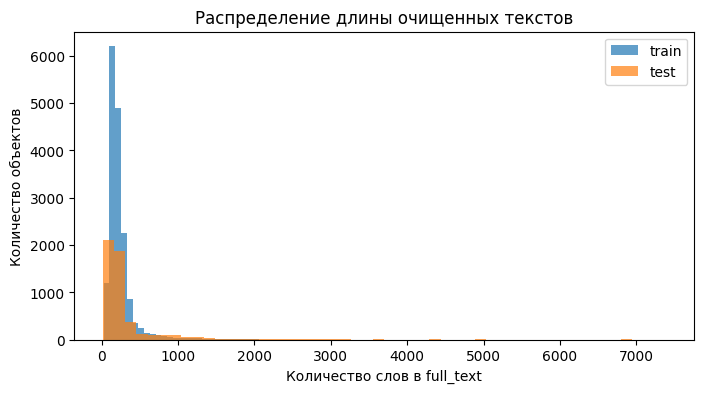

In [59]:
plt.figure(figsize=(8, 4))

plt.hist(train_data["full_text_word_count"], bins=50, alpha=0.7, label="train")
plt.hist(test_data["full_text_word_count"], bins=50, alpha=0.7, label="test")

plt.title("Распределение длины очищенных текстов")
plt.xlabel("Количество слов в full_text")
plt.ylabel("Количество объектов")
plt.legend()

plt.show()

После очистки большая часть текстов осталась умеренной длины. В обучающей выборке медианная длина `full_text` составляет 189 слов, а 75% текстов имеют длину не более 257 слов. При этом есть длинный правый хвост: 99-й процентиль в трейн равен 1028 словам. В тестовой выборке длинных текстов больше: 90-й процентиль составляет около 618 слов, 95-й около 995 слов, а 99-й более 2000 слов. Это говорит о том, что тест содержит больше длинных объектов, чем трейн (ну либо мы его как-то хуже почистили)

In [60]:
def count_emojis(text):
    text = str(text)
    return emoji.emoji_count(text)

def has_emoji(text):
    return count_emojis(text) > 0

In [61]:
for data in [train_data, test_data]:
    data["title_emoji_count"] = data[title_column].apply(count_emojis)
    data["text_emoji_count"] = data[text_column].apply(count_emojis)
    data["total_emoji_count"] = data["title_emoji_count"] + data["text_emoji_count"]

    data["has_emoji"] = data["total_emoji_count"] > 0

In [62]:
emoji_summary = pd.DataFrame({
    "train": [
        train_data["has_emoji"].sum(),
        train_data["has_emoji"].mean(),
        train_data["total_emoji_count"].sum(),
        train_data["total_emoji_count"].mean(),
        train_data["total_emoji_count"].median(),
        train_data["total_emoji_count"].max()
    ],
    "test": [
        test_data["has_emoji"].sum(),
        test_data["has_emoji"].mean(),
        test_data["total_emoji_count"].sum(),
        test_data["total_emoji_count"].mean(),
        test_data["total_emoji_count"].median(),
        test_data["total_emoji_count"].max()
    ]
}, index=[
    "объектов с эмодзи",
    "доля объектов с эмодзи",
    "всего эмодзи",
    "среднее число эмодзи на объект",
    "медиана числа эмодзи",
    "максимум эмодзи в объекте"
])

display(emoji_summary)

,train,test
объектов с эмодзи,16682.000000,106.000000
доля объектов с эмодзи,0.998862,0.021332
всего эмодзи,276009.000000,205.000000
среднее число эмодзи на объект,16.526495,0.041256
медиана числа эмодзи,16.000000,0.000000
максимум эмодзи в объекте,45.000000,7.000000


Эмодзи получается у нас артефакт, то есть их лучше удалить, чтобы трейн был больше похож на тест

Проведем теперь анализ других артефактов

In [63]:
def count_pattern(text, pattern):
    text = str(text)
    return len(re.findall(pattern, text, flags=re.IGNORECASE | re.DOTALL))

artifact_patterns = {
    "html_tags": r"<[^>]+>",
    "html_entities": r"&[a-zA-Z]+;|&#\d+;",
    "cdata": r"<!\[CDATA\[",
    "xml_header": r"<\?xml",
    "html_comments": r"<!--.*?-->",
    "broken_tags_words": r"\b(content|source|title|span|div|p|br|em|strong|blockquote|article|section|news|item|text|time|url|doc|body|ul|li|b|i|u|hr|meta)\b",
    "urls": r"http[s]?://|www\.",
    "latin_words": r"\b[a-zA-Z]{3,}\b",
    "digits": r"\d+",
    "special_symbols": r"[^\w\sА-Яа-яЁё.,!?;:()«»\"'%-]"
}

def add_artifact_features(data, prefix):
    full_raw = data[title_column].astype(str) + " " + data[text_column].astype(str)
    
    for feature_name, pattern in artifact_patterns.items():
        data[f"{prefix}_{feature_name}_count"] = full_raw.apply(
            lambda text: count_pattern(text, pattern)
        )
    
    return data

train_data = add_artifact_features(train_data, "artifact")
test_data = add_artifact_features(test_data, "artifact")

In [64]:
artifact_columns = [
    column for column in train_data.columns
    if column.startswith("artifact_")
]

artifact_summary = []

for column in artifact_columns:
    artifact_summary.append({
        "feature": column,
        "train_mean": train_data[column].mean(),
        "test_mean": test_data[column].mean(),
        "train_median": train_data[column].median(),
        "test_median": test_data[column].median(),
        "train_share_positive": (train_data[column] > 0).mean(),
        "test_share_positive": (test_data[column] > 0).mean(),
        "mean_ratio_train_to_test": train_data[column].mean() / (test_data[column].mean() + 1e-8)
    })

artifact_summary = pd.DataFrame(artifact_summary).sort_values(
    "mean_ratio_train_to_test",
    ascending=False
)

display(artifact_summary)

,feature,train_mean,test_mean,train_median,test_median,train_share_positive,test_share_positive,mean_ratio_train_to_test
1,artifact_html_entities_count,10.069517,0.000000,10.0,0.0,0.993713,0.000000,1.006952e+09
4,artifact_html_comments_count,1.689719,0.000000,1.0,0.0,0.758877,0.000000,1.689719e+08
2,artifact_cdata_count,0.878031,0.000000,1.0,0.0,0.549548,0.000000,8.780313e+07
3,artifact_xml_header_count,0.272439,0.000000,0.0,0.0,0.231483,0.000000,2.724388e+07
0,artifact_html_tags_count,33.074008,0.031395,33.0,0.0,1.000000,0.019722,1.053492e+03
5,artifact_broken_tags_words_count,33.254775,0.094184,33.0,0.0,1.000000,0.048299,3.530832e+02
9,artifact_special_symbols_count,131.048740,6.630509,131.0,3.0,1.000000,0.808010,1.976451e+01
7,artifact_latin_words_count,41.186157,4.379956,40.0,1.0,1.000000,0.630308,9.403327e+00
8,artifact_digits_count,13.191965,8.444757,10.0,5.0,0.999341,0.939827,1.562148e+00
6,artifact_urls_count,0.000719,0.041256,0.0,0.0,0.000659,0.021534,1.741622e-02


In [65]:
def extract_html_tag_names(text):
    text = str(text)
    tags = re.findall(r"</?\s*([a-zA-Z0-9_:-]+)", text)
    return [tag.lower() for tag in tags]

def get_tag_counter(data):
    counter = Counter()
    full_raw = data[title_column].astype(str) + " " + data[text_column].astype(str)
    
    for text in full_raw:
        counter.update(extract_html_tag_names(text))
    
    return counter

train_tag_counter = get_tag_counter(train_data)
test_tag_counter = get_tag_counter(test_data)

train_top_tags = pd.DataFrame(
    train_tag_counter.most_common(30),
    columns=["tag", "train_count"]
)

test_top_tags = pd.DataFrame(
    test_tag_counter.most_common(30),
    columns=["tag", "test_count"]
)

tag_comparison = train_top_tags.merge(
    test_top_tags,
    on="tag",
    how="outer"
).fillna(0)

tag_comparison["train_count"] = tag_comparison["train_count"].astype(int)
tag_comparison["test_count"] = tag_comparison["test_count"].astype(int)

tag_comparison["train_to_test_ratio"] = (
    tag_comparison["train_count"] / (tag_comparison["test_count"] + 1)
)

display(tag_comparison.sort_values("train_to_test_ratio", ascending=False).head(50))

,tag,train_count,test_count,train_to_test_ratio
20,span,89359,0,89359.0
8,div,30168,0,30168.0
12,i,30144,0,30144.0
7,content,29984,0,29984.0
3,b,29900,0,29900.0
24,title,29900,0,29900.0
21,strong,29705,0,29705.0
10,em,29606,0,29606.0
22,text,20534,0,20534.0
17,p,39353,1,19676.5


In [66]:
source_artifact_columns = [
    "total_emoji_count",
    "artifact_html_tags_count",
    "artifact_html_entities_count",
    "artifact_cdata_count",
    "artifact_xml_header_count",
    "artifact_html_comments_count",
    "artifact_broken_tags_words_count",
    "artifact_special_symbols_count"
]

train_source_artifacts = train_data.groupby(source_column)[source_artifact_columns].mean()
test_source_artifacts = test_data.groupby(source_column)[source_artifact_columns].mean()

print("Train source artifacts:")
display(train_source_artifacts)

print("Test source artifacts:")
display(test_source_artifacts)

Train source artifacts:


,total_emoji_count,artifact_html_tags_count,artifact_html_entities_count,artifact_cdata_count,artifact_xml_header_count,artifact_html_comments_count,artifact_broken_tags_words_count,artifact_special_symbols_count
source,,,,,,,,
Novosti,16.551219,33.188808,10.118896,0.873266,0.272435,1.690415,33.333333,131.463986
Svezhesti,16.446474,32.702435,9.909691,0.893455,0.272451,1.687468,33.000507,129.704718


Test source artifacts:


,total_emoji_count,artifact_html_tags_count,artifact_html_entities_count,artifact_cdata_count,artifact_xml_header_count,artifact_html_comments_count,artifact_broken_tags_words_count,artifact_special_symbols_count
source,,,,,,,,
Novosti,0.000000,0.036072,0.0,0.0,0.0,0.0,0.050100,5.044088
Spletnesti,0.083045,0.024221,0.0,0.0,0.0,0.0,0.246828,10.572088
Svezhesti,0.001761,0.000000,0.0,0.0,0.0,0.0,0.093310,1.904930
Zholtosti,0.085826,0.040962,0.0,0.0,0.0,0.0,0.065670,8.212614


In [67]:
for data in [train_data, test_data]:
    data["raw_title_chars"] = data[title_column].astype(str).apply(len)
    data["raw_text_chars"] = data[text_column].astype(str).apply(len)
    data["raw_full_chars"] = data["raw_title_chars"] + data["raw_text_chars"]
    
    data["raw_title_words"] = data[title_column].astype(str).apply(lambda x: len(x.split()))
    data["raw_text_words"] = data[text_column].astype(str).apply(lambda x: len(x.split()))
    data["raw_full_words"] = data["raw_title_words"] + data["raw_text_words"]

length_comparison = pd.DataFrame({
    "train_raw_full_words": train_data["raw_full_words"].describe(),
    "test_raw_full_words": test_data["raw_full_words"].describe(),
    "train_raw_full_chars": train_data["raw_full_chars"].describe(),
    "test_raw_full_chars": test_data["raw_full_chars"].describe()
})

display(length_comparison)

,train_raw_full_words,test_raw_full_words,train_raw_full_chars,test_raw_full_chars
count,16701.000000,4969.000000,16701.000000,4969.000000
mean,276.776959,297.909640,2123.002515,2690.165627
std,183.677844,450.841367,1360.487732,3347.911252
min,49.000000,12.000000,413.000000,110.000000
25%,184.000000,123.000000,1429.000000,918.000000
50%,234.000000,179.000000,1822.000000,1425.000000
75%,306.000000,271.000000,2355.000000,3534.000000
max,3881.000000,7596.000000,26295.000000,47411.000000


In [68]:
labels = train_data[target_columns].values.astype(np.float32)

print("Размер матрицы целевых меток:", labels.shape)

Размер матрицы целевых меток: (16701, 5)


Дальше идет очистка более подробная

In [69]:
def clean_text_v3(text):
    text = str(text)

    text = html.unescape(text)

    text = emoji.replace_emoji(text, replace=" ")

    text = text.replace("<![CDATA[", " ")
    text = text.replace("]]>", " ")

    text = re.sub(r"<\?xml.*?\?>", " ", text, flags=re.DOTALL)
    text = re.sub(r"<!--.*?-->", " ", text, flags=re.DOTALL)

    text = re.sub(r"<[^>]+>", " ", text)

    text = re.sub(r"&[a-zA-Z]+;|&#\d+;", " ", text)

    text = re.sub(
        r"\b(content|source|title|span|div|p|br|em|strong|blockquote|article|section|news|item|text|time|url|doc|body|ul|li|b|i|u|hr|meta|author)\b",
        " ",
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(r"http[s]?://\S+|www\.\S+", " URL ", text)

    text = re.sub(r"[^\w\sА-Яа-яЁё.,!?;:()«»\"'%-]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

In [70]:
train_data["clean_title_v3"] = train_data[title_column].apply(clean_text_v3)
train_data["clean_text_v3"] = train_data[text_column].apply(clean_text_v3)

test_data["clean_title_v3"] = test_data[title_column].apply(clean_text_v3)
test_data["clean_text_v3"] = test_data[text_column].apply(clean_text_v3)

train_data["model_text_v3"] = train_data["clean_title_v3"] + ". " + train_data["clean_text_v3"]
test_data["model_text_v3"] = test_data["clean_title_v3"] + ". " + test_data["clean_text_v3"]

In [71]:
def count_pattern(text, pattern):
    text = str(text)
    return len(re.findall(pattern, text, flags=re.IGNORECASE | re.DOTALL))

def count_emojis(text):
    text = str(text)
    return emoji.emoji_count(text)

In [72]:
for data_name, data in [("train", train_data), ("test", test_data)]:
    emoji_count_after = (
        data["clean_title_v3"].apply(count_emojis)
        + data["clean_text_v3"].apply(count_emojis)
    ).sum()

    html_count_after = data["model_text_v3"].apply(
        lambda text: count_pattern(text, r"<[^>]+>")
    ).sum()

    entity_count_after = data["model_text_v3"].apply(
        lambda text: count_pattern(text, r"&[a-zA-Z]+;|&#\d+;")
    ).sum()

    cdata_count_after = data["model_text_v3"].apply(
        lambda text: count_pattern(text, r"<!\[CDATA\[")
    ).sum()

    xml_count_after = data["model_text_v3"].apply(
        lambda text: count_pattern(text, r"<\?xml")
    ).sum()

    comment_count_after = data["model_text_v3"].apply(
        lambda text: count_pattern(text, r"<!--.*?-->")
    ).sum()

    print(data_name)
    print("emoji after cleaning:", emoji_count_after)
    print("html tags after cleaning:", html_count_after)
    print("html entities after cleaning:", entity_count_after)
    print("CDATA after cleaning:", cdata_count_after)
    print("XML after cleaning:", xml_count_after)
    print("comments after cleaning:", comment_count_after)
    print()

train
emoji after cleaning: 0
html tags after cleaning: 0
html entities after cleaning: 0
CDATA after cleaning: 0
XML after cleaning: 0
comments after cleaning: 0

test
emoji after cleaning: 0
html tags after cleaning: 0
html entities after cleaning: 0
CDATA after cleaning: 0
XML after cleaning: 0
comments after cleaning: 0



Вот тут реализована очень инетересная идея. Так как у нас в данных заметен сдвиг между обучающей и тестовой выборкой, полезно отдельно проверить, насколько легко модель может отличить тексты из трейна от текстов из теста. Для этого создаём искусственную бинарную задачу: 0 — объект из трейна, 1 — объект из теста. Затем обучаем простую модель на TF-IDF признаках текста и считаем ROC-AUC. Если ROC-AUC близок к 0.5, значит трейн и тест почти неотличимы.мЕсли ROC-AUC сильно выше 0.5, значит между выборками есть заметный сдвиг

Эта проверка нужна, чтобы сравнивать разные варианты очистки текста: чем ниже adversarial ROC-AUC после очистки, тем более похожими становятся трейн и тест, тем лучше для нас, потому что модели булет проще, она будет обучаться почти на том же, что ей нужно будет предсказать

In [73]:
def adversarial_auc_for_text_column(text_column):
    domain_texts = pd.concat(
        [train_data[text_column], test_data[text_column]],
        axis=0
    ).reset_index(drop=True)

    domain_labels = np.array([0] * len(train_data) + [1] * len(test_data))

    vectorizer = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=3,
        max_features=150000,
        sublinear_tf=True
    )

    features = vectorizer.fit_transform(domain_texts)

    splitter = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    scores = []

    for train_index, valid_index in splitter.split(features, domain_labels):
        model = LogisticRegression(
            C=2.0,
            max_iter=3000,
            solver="liblinear",
            random_state=seed
        )

        model.fit(features[train_index], domain_labels[train_index])

        probabilities = model.predict_proba(features[valid_index])[:, 1]
        score = roc_auc_score(domain_labels[valid_index], probabilities)

        scores.append(score)

    return np.mean(scores), np.std(scores)

In [74]:
train_data["model_text_raw"] = (
    train_data[title_column].astype(str) + ". " + train_data[text_column].astype(str)
)

test_data["model_text_raw"] = (
    test_data[title_column].astype(str) + ". " + test_data[text_column].astype(str)
)

In [75]:
def show_domain_top_features(text_column, top_n=80):
    domain_texts = pd.concat(
        [train_data[text_column], test_data[text_column]],
        axis=0
    ).reset_index(drop=True)

    domain_labels = np.array([0] * len(train_data) + [1] * len(test_data))

    vectorizer = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=3,
        max_features=150000,
        sublinear_tf=True
    )

    features = vectorizer.fit_transform(domain_texts)

    model = LogisticRegression(
        C=2.0,
        max_iter=3000,
        solver="liblinear",
        random_state=seed
    )

    model.fit(features, domain_labels)

    feature_names = np.array(vectorizer.get_feature_names_out())
    coefficients = model.coef_[0]

    top_test_indices = np.argsort(coefficients)[-top_n:][::-1]
    top_train_indices = np.argsort(coefficients)[:top_n]

    top_test_features = pd.DataFrame({
        "feature": feature_names[top_test_indices],
        "coefficient": coefficients[top_test_indices]
    })

    top_train_features = pd.DataFrame({
        "feature": feature_names[top_train_indices],
        "coefficient": coefficients[top_train_indices]
    })

    print("Признаки, характерные для test:")
    display(top_test_features)

    print("Признаки, характерные для train:")
    display(top_train_features)

    return top_test_features, top_train_features

In [76]:
def clean_text_v4(text):
    text = clean_text_v3(text)

    month_pattern = (
        r"\b("
        r"января|февраля|марта|апреля|мая|июня|июля|августа|сентября|октября|ноября|декабря|"
        r"янв|фев|мар|апр|июн|июл|авг|сен|сент|окт|ноя|дек"
        r")\b"
    )
    text = re.sub(month_pattern, " MONTH ", text, flags=re.IGNORECASE)

    text = re.sub(r"\b\d{1,2}[./-]\d{1,2}[./-]\d{2,4}\b", " DATE ", text)
    text = re.sub(r"\b\d{4}[./-]\d{1,2}[./-]\d{1,2}\b", " DATE ", text)

    text = re.sub(r"\b\d{1,2}:\d{2}\b", " TIME ", text)

    text = re.sub(r"\b\d+([,.]\d+)?\s*%", " PERCENT ", text)
    text = re.sub(r"\b\d{5,}\b", " NUMBER ", text)

    text = re.sub(r"\bРИА Новости\b", " NEWS_AGENCY ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bНовости\b", " NEWS ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bИнтерфакс\b", " NEWS_AGENCY ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bТАСС\b", " NEWS_AGENCY ", text, flags=re.IGNORECASE)

    text = re.sub(
        r"\b(highlight|class|quote|cached|viewport|charset|utf|xml|wp|paragraph)\b",
        " ",
        text,
        flags=re.IGNORECASE
    )

    text = text.replace("«", " ")
    text = text.replace("»", " ")
    text = text.replace('"', " ")
    text = text.replace("'", " ")

    text = re.sub(r"([!?.,:;])\1+", r"\1", text)

    text = re.sub(r"[.,:;]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

In [77]:
train_data["clean_title_v4"] = train_data[title_column].apply(clean_text_v4)
train_data["clean_text_v4"] = train_data[text_column].apply(clean_text_v4)

test_data["clean_title_v4"] = test_data[title_column].apply(clean_text_v4)
test_data["clean_text_v4"] = test_data[text_column].apply(clean_text_v4)

train_data["model_text_v4"] = train_data["clean_title_v4"] + ". " + train_data["clean_text_v4"]
test_data["model_text_v4"] = test_data["clean_title_v4"] + ". " + test_data["clean_text_v4"]

In [78]:
def clean_text_v5(text):
    text = clean_text_v4(text)

    text = re.sub(r"\b\d+([,.]\d+)?\b", " NUMBER ", text)

    text = re.sub(r"(NUMBER\s+){2,}", " NUMBER ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

In [79]:
train_data["clean_title_v5"] = train_data[title_column].apply(clean_text_v5)
train_data["clean_text_v5"] = train_data[text_column].apply(clean_text_v5)

test_data["clean_title_v5"] = test_data[title_column].apply(clean_text_v5)
test_data["clean_text_v5"] = test_data[text_column].apply(clean_text_v5)

train_data["model_text_v5"] = (
    train_data["clean_title_v5"] + ". " + train_data["clean_text_v5"]
)

test_data["model_text_v5"] = (
    test_data["clean_title_v5"] + ". " + test_data["clean_text_v5"]
)

In [80]:
def get_first_words(text, n_words):
    words = str(text).split()
    return " ".join(words[:n_words])


for n_words in [250, 350, 450, 600]:
    train_data[f"model_text_v4_cut{n_words}"] = train_data["model_text_v4"].apply(
        lambda text: get_first_words(text, n_words)
    )

    test_data[f"model_text_v4_cut{n_words}"] = test_data["model_text_v4"].apply(
        lambda text: get_first_words(text, n_words)
    )

In [81]:
top_test_features_cut350, top_train_features_cut350 = show_domain_top_features(
    "model_text_v4_cut350",
    top_n=50
)

Признаки, характерные для test:


,feature,coefficient
0,сатьс,3.327674
1,дуз,3.062405
2,едуз,3.062405
3,медуз,3.062405
4,исать,3.026751
5,сать,2.969690
6,писат,2.716265
7,исат,2.714522
8,меду,2.577314
9,меду,2.568860


Признаки, характерные для train:


,feature,coefficient
0,-,-7.043942
1,ria,-6.819931
2,ria,-6.792983
3,ria,-6.763452
4,ria,-6.757844
5,ri,-6.663254
6,ia,-6.526404
7,ru,-5.973201
8,ru,-5.953228
9,ru,-5.888496


In [82]:
def clean_text_v6(text):
    text = clean_text_v4(text)

    text = re.sub(r"\bria\.ru\b", " NEWS_SOURCE ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bria\b", " NEWS_SOURCE ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bmeduza\b", " NEWS_SOURCE ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bмедуза\b", " NEWS_SOURCE ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bинтерфакс\b", " NEWS_SOURCE ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bтасс\b", " NEWS_SOURCE ", text, flags=re.IGNORECASE)

    text = re.sub(r"\bподписаться\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bподписывайтесь\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bподписка\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\btelegram\b", " SOCIAL ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bтелеграм\b", " SOCIAL ", text, flags=re.IGNORECASE)
    text = re.sub(r"\binstagram\b", " SOCIAL ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bfacebook\b", " SOCIAL ", text, flags=re.IGNORECASE)
    text = re.sub(r"\btwitter\b", " SOCIAL ", text, flags=re.IGNORECASE)

    text = re.sub(
        r"\b(page|date|cache|cached|image|photo|video|high|highlight|class|quote|source|author|news|content)\b",
        " ",
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(r"[-–—]+", " ", text)

    text = re.sub(r"\b[a-zA-Z]{2,4}\b", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

In [83]:
train_data["clean_title_v6"] = train_data[title_column].apply(clean_text_v6)
train_data["clean_text_v6"] = train_data[text_column].apply(clean_text_v6)

test_data["clean_title_v6"] = test_data[title_column].apply(clean_text_v6)
test_data["clean_text_v6"] = test_data[text_column].apply(clean_text_v6)

train_data["model_text_v6"] = train_data["clean_title_v6"] + ". " + train_data["clean_text_v6"]
test_data["model_text_v6"] = test_data["clean_title_v6"] + ". " + test_data["clean_text_v6"]

In [84]:
def make_title_plus_text_head(title, text, n_words=350):
    words = str(text).split()
    text_head = " ".join(words[:n_words])
    return str(title) + ". " + text_head


for n_words in [250, 350, 450]:
    train_data[f"model_text_v4_title_head{n_words}"] = train_data.apply(
        lambda row: make_title_plus_text_head(
            row["clean_title_v4"],
            row["clean_text_v4"],
            n_words
        ),
        axis=1
    )

    test_data[f"model_text_v4_title_head{n_words}"] = test_data.apply(
        lambda row: make_title_plus_text_head(
            row["clean_title_v4"],
            row["clean_text_v4"],
            n_words
        ),
        axis=1
    )

In [85]:
for n_words in [250, 350, 450]:
    train_data[f"model_text_v6_title_head{n_words}"] = train_data.apply(
        lambda row: make_title_plus_text_head(
            row["clean_title_v6"],
            row["clean_text_v6"],
            n_words
        ),
        axis=1
    )

    test_data[f"model_text_v6_title_head{n_words}"] = test_data.apply(
        lambda row: make_title_plus_text_head(
            row["clean_title_v6"],
            row["clean_text_v6"],
            n_words
        ),
        axis=1
    )

In [86]:
text_columns_to_check = [
    "model_text_raw",
    "model_text_v3",
    "model_text_v4_title_head350",
    "model_text_v5",
    "model_text_v6_title_head250",
]

adversarial_v6_results = []

for column in text_columns_to_check:
    mean_auc, std_auc = adversarial_auc_for_text_column(column)

    adversarial_v6_results.append({
        "text_column": column,
        "adversarial_auc_mean": mean_auc,
        "adversarial_auc_std": std_auc
    })

adversarial_v6_results = pd.DataFrame(adversarial_v6_results).sort_values(
    "adversarial_auc_mean"
)

display(adversarial_v6_results)

,text_column,adversarial_auc_mean,adversarial_auc_std
4,model_text_v6_title_head250,0.904515,0.002184
2,model_text_v4_title_head350,0.910634,0.002850
3,model_text_v5,0.911801,0.003709
1,model_text_v3,0.982074,0.001255
0,model_text_raw,0.999960,0.000027


In [87]:
top_test_features_v6_250, top_train_features_v6_250 = show_domain_top_features(
    "model_text_v6_title_head250",
    top_n=50
)

Признаки, характерные для test:


,feature,coefficient
0,адки,3.013262
1,акла,2.992580
2,закла,2.976755
3,аклад,2.965631
4,ладки,2.965152
5,адки,2.886082
6,кладк,2.880120
7,дки,2.719283
8,ладк,2.565480
9,дки,2.531980


Признаки, характерные для train:


,feature,coefficient
0,quo,-4.107467
1,uo,-4.090455
2,quo,-4.090455
3,ce,-3.944943
4,rce,-3.594919
5,urc,-3.587535
6,s_so,-3.581055
7,sourc,-3.579792
8,ource,-3.579792
9,urce,-3.579792


In [100]:
def clean_text_v7(text):
    text = clean_text_v4(text)

    text = re.sub(r"\bria\.ru\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bria\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bмедуза\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bmeduza\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bинтерфакс\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bтасс\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bновости\b", " ", text, flags=re.IGNORECASE)

    text = re.sub(r"\bподписаться\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bподписывайтесь\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bподписка\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bотписаться\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bотписка\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bзакладки\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bзакладка\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bкомментарии\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bкомментарий\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bкомментировать\b", " ", text, flags=re.IGNORECASE)

    text = re.sub(r"\btelegram\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bтелеграм\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\binstagram\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bfacebook\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\btwitter\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\byoutube\b", " ", text, flags=re.IGNORECASE)

    text = re.sub(
        r"\b(news_source|news_agency|source|news|quo|quote|dash|ndash|mdash|width|height|page|date|cache|cached|image|photo|video|highlight|class|author|content)\b",
        " ",
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(r"\b[a-zA-Z]{2,5}\b", " ", text)

    text = re.sub(r"[-–—]+", " ", text)
    text = re.sub(r"[.,:;]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

In [101]:
train_data["clean_title_v7"] = train_data[title_column].apply(clean_text_v7)
train_data["clean_text_v7"] = train_data[text_column].apply(clean_text_v7)

test_data["clean_title_v7"] = test_data[title_column].apply(clean_text_v7)
test_data["clean_text_v7"] = test_data[text_column].apply(clean_text_v7)

train_data["model_text_v7"] = train_data["clean_title_v7"] + ". " + train_data["clean_text_v7"]
test_data["model_text_v7"] = test_data["clean_title_v7"] + ". " + test_data["clean_text_v7"]

In [102]:
for n_words in [250, 350, 450]:
    train_data[f"model_text_v7_title_head{n_words}"] = train_data.apply(
        lambda row: make_title_plus_text_head(
            row["clean_title_v7"],
            row["clean_text_v7"],
            n_words
        ),
        axis=1
    )

    test_data[f"model_text_v7_title_head{n_words}"] = test_data.apply(
        lambda row: make_title_plus_text_head(
            row["clean_title_v7"],
            row["clean_text_v7"],
            n_words
        ),
        axis=1
    )

In [104]:
def clean_text_v8(text):
    text = clean_text_v7(text)

    text = re.sub(
        r"\b(160|171|187|8211|8212|8230|8220|8221|039|amp|nbsp|quot)\b",
        " ",
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(r"\b\d+([,.]\d+)?\s*PERCENT\b", " PERCENT ", text)
    text = re.sub(r"\b\d+\s+\d+\s*PERCENT\b", " PERCENT ", text)

    text = re.sub(r"\(\s*PERCENT\s*\)", " PERCENT ", text)
    text = re.sub(r"\(\s*NUMBER\s*\)", " NUMBER ", text)

    text = re.sub(r"(PERCENT\s+){2,}", " PERCENT ", text)
    text = re.sub(r"(NUMBER\s+){2,}", " NUMBER ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

In [105]:
train_data["clean_title_v8"] = train_data[title_column].apply(clean_text_v8)
train_data["clean_text_v8"] = train_data[text_column].apply(clean_text_v8)

test_data["clean_title_v8"] = test_data[title_column].apply(clean_text_v8)
test_data["clean_text_v8"] = test_data[text_column].apply(clean_text_v8)

for n_words in [250, 350]:
    train_data[f"model_text_v8_title_head{n_words}"] = train_data.apply(
        lambda row: make_title_plus_text_head(
            row["clean_title_v8"],
            row["clean_text_v8"],
            n_words
        ),
        axis=1
    )

    test_data[f"model_text_v8_title_head{n_words}"] = test_data.apply(
        lambda row: make_title_plus_text_head(
            row["clean_title_v8"],
            row["clean_text_v8"],
            n_words
        ),
        axis=1
    )

In [106]:
text_columns_to_check = [
    "model_text_v7_title_head250",
    "model_text_v7_title_head350",
    "model_text_v8_title_head250",
    "model_text_v8_title_head350",
]

adversarial_v8_results = []

for column in text_columns_to_check:
    mean_auc, std_auc = adversarial_auc_for_text_column(column)

    adversarial_v8_results.append({
        "text_column": column,
        "adversarial_auc_mean": mean_auc,
        "adversarial_auc_std": std_auc
    })

adversarial_v8_results = pd.DataFrame(adversarial_v8_results).sort_values(
    "adversarial_auc_mean"
)

display(adversarial_v8_results)

,text_column,adversarial_auc_mean,adversarial_auc_std
2,model_text_v8_title_head250,0.875530,0.004410
0,model_text_v7_title_head250,0.877057,0.004358
3,model_text_v8_title_head350,0.878242,0.004811
1,model_text_v7_title_head350,0.879693,0.004806


Это лучшее значение до которого я тут смогла дойти, тк у нас тест и трейн отличаются все-таки не только самим "видом" текста, а и источниками, длиной и еще много чем, но снизить это с практически 1 тоже думаю должно помочь моделе

Посмотрим, на чем по итогу будем обучать наши модели

In [107]:
model_text_column = "model_text_v8_title_head350"

In [108]:
def show_model_text_examples(data, text_column, n=3, max_words=180):
    for i in range(min(n, len(data))):
        text = str(data[text_column].iloc[i])
        words = text.split()
        short_text = " ".join(words[:max_words])

        if len(words) > max_words:
            short_text += " ..."

        display(Markdown(f"""
### Пример {i + 1}

**Заголовок:** {data[title_column].iloc[i]}

**Текст для модели:**

> {short_text}
"""))

In [109]:
show_model_text_examples(
    train_data,
    model_text_column,
    n=3,
    max_words=180
)


### Пример 1

**Заголовок:** Рейтинг регионов по уровню закредитованности населения — 2019

**Текст для модели:**

> Рейтинг регионов по уровню закредитованности населения 2019. Средний уровень закредитованности россиян вырос за 2019 год с 44 9 до PERCENT Больше всего банкам должны жители Калмыкии PERCENT меньше всего Ингушетии PERCENT Смотрите в инфографике какая долговая нагрузка у населения вашего региона



### Пример 2

**Заголовок:** Названы самые закредитованные российские регионы

**Текст для модели:**

> Названы самые закредитованные российские регионы. МОСКВА 23 Наиболее закредитованным субъектом Российской Федерации является Калмыкия по объемам долга в среднем на человека лидируют северные регионы меньше всего займов взяли на юге свидетельствуют результаты исследования Если в 2017 и 2018 годах в основном росло залоговое кредитование (ипотека и автокредиты) то теперь резко ускорился беззалоговый сегмент Потребительское кредитование демонстрирует активный рост на фоне снижения процентных ставок Кроме того это происходит при умеренных темпах увеличения заработной платы что приводит к усилению долговой нагрузки россиян Данные показывают что объем кредитов населения за 12 месяцев (по состоянию на 1 2019 года) вырос на PERCENT до 17 2 триллиона рублей При этом средняя номинальная зарплата за последний год выросла значительно меньше на PERCENT По оценкам экспертов суммарный долг в среднем на одного экономически активного жителя страны за год увеличился на 37 тысяч рублей до 227 тысяч Таким образом закредитованность населения которую можно определить как отношение долга к годовой заработанной плате растет достаточно быстро с PERCENT в 2018 году до PERCENT в текущем рейтинге Ситуация с долговой нагрузкой населения в разных регионах достаточно неоднородная отношение кредитов к годовой ...



### Пример 3

**Заголовок:** В России пройдут учения по обеспечению устойчивой работы рунета 

**Текст для модели:**

> В России пройдут учения по обеспечению устойчивой работы рунета. МОСКВА 23 Всероссийские учения по обеспечению устойчивой работы рунета и сети связи общего пользования пройдут в понедельник в них примут участие операторы связи и органы власти Учения будут носить исследовательский характер обычные абоненты и интернет пользователи не заметят их подчеркивали в Минкомсвязи Проведение учений предусмотрено законом об устойчивой работе рунета вступившим в силу с 1 Подчеркну что пользователи учения не заметят Ни о какой изоляции рунета речи нет сказал пресс секретарь Минкомсвязи Евгений Новиков Он добавил что для проведения учений все готово Ранее он рассказывал что отработка угроз будет проводиться только на выделенных сегментах стендах и полигонах поэтому обычные пользователи учений не заметят По его словам такие учения будут проводиться на регулярной основе и на них планируется отрабатывать весь спектр потенциальных воздействий на сети связи Правительство в октябре утвердило положение о проведении в РФ учений по обеспечению устойчивого безопасного и целостного функционирования интернета и сети связи общего пользования Постановление вступившее в силу с 1 предусматривает что учения проводятся по решению Минкомсвязи на федеральном и региональном (на территории одного или нескольких субъектов ...


Следующая интересная идея, это выделить из трейна часть, которая более всего похожа на тест и потом ее использовать для создания специальны фолдов для обучения модели 

In [110]:
def get_test_likeness(text_column):
    domain_texts = pd.concat(
        [
            train_data[text_column],
            test_data[text_column]
        ],
        axis=0
    ).reset_index(drop=True)

    domain_labels = np.array(
        [0] * len(train_data) + [1] * len(test_data)
    )

    vectorizer = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=3,
        max_features=150000,
        sublinear_tf=True
    )

    domain_features = vectorizer.fit_transform(domain_texts)

    domain_model = LogisticRegression(
        C=2.0,
        max_iter=3000,
        solver="liblinear",
        random_state=seed
    )

    domain_model.fit(domain_features, domain_labels)

    domain_probabilities = domain_model.predict_proba(domain_features)[:, 1]

    train_test_likeness = domain_probabilities[:len(train_data)]
    test_test_likeness = domain_probabilities[len(train_data):]

    return train_test_likeness, test_test_likeness

In [111]:
train_test_likeness, test_test_likeness = get_test_likeness(
    "model_text_v8_title_head250"
)

train_data["test_likeness"] = train_test_likeness
test_data["test_likeness"] = test_test_likeness

print("Test-likeness для train:")
display(train_data["test_likeness"].describe())

print("Test-likeness для test:")
display(test_data["test_likeness"].describe())

Test-likeness для train:


count    16701.000000
mean         0.122122
std          0.095231
min          0.000566
25%          0.050784
50%          0.098926
75%          0.169549
max          0.801405
Name: test_likeness, dtype: float64

Test-likeness для test:


count    4969.000000
mean        0.589453
std         0.229341
min         0.008605
25%         0.412139
50%         0.588848
75%         0.777014
max         0.999320
Name: test_likeness, dtype: float64

In [112]:
display(
    train_data
    .sort_values("test_likeness", ascending=False)
    [
        [id_column, source_column, date_column, title_column, "test_likeness", target_column]
    ]
    .head(30)
)

,id,source,publication_date,title,test_likeness,target
13678,13678,Svezhesti,2020-06-21 23:58:00,Белорусы по всему миру устроили акции в поддер...,0.801405,"[1, 0, 0, 0, 0]"
10623,10623,Svezhesti,2020-05-13 19:21:00,Версию о создании коронавируса для борьбы с пе...,0.799602,"[1, 0, 0, 0, 0]"
14902,14902,Svezhesti,2020-07-07 19:34:00,Белорусское МВД выпустило видео с извинениями ...,0.765319,"[1, 0, 0, 0, 0]"
11883,11883,Svezhesti,2020-05-29 23:29:00,В Белоруссии задержан планировавший участвоват...,0.764480,"[1, 0, 0, 0, 0]"
15284,15284,Svezhesti,2020-07-12 14:35:00,Стас Михайлов прервал выступление и промок рад...,0.727858,"[1, 0, 0, 0, 0]"
15682,15682,Svezhesti,2020-07-17 20:13:00,Лукашенко рассказал о творящихся на белорусски...,0.713894,"[1, 0, 0, 0, 0]"
13977,13977,Svezhesti,2020-06-25 19:37:00,Глава МВД Белоруссии рассказал про «ласковые н...,0.682020,"[1, 1, 0, 0, 0]"
15367,15367,Svezhesti,2020-07-13 20:20:00,МВД Белоруссии пригрозило блокировать соцсети ...,0.670074,"[1, 0, 0, 0, 0]"
3722,3722,Svezhesti,2020-02-14 17:32:00,Белоруссия пригрозила оштрафовать Россию,0.666832,"[1, 1, 0, 0, 0]"
15690,15690,Svezhesti,2020-07-17 22:38:00,Мишустин и Лукашенко пошутили про «менее зараз...,0.664856,"[1, 0, 0, 0, 0]"


In [113]:
display(
    train_data
    .sort_values("test_likeness", ascending=True)
    [
        [id_column, source_column, date_column, title_column, "test_likeness", target_column]
    ]
    .head(30)
)

,id,source,publication_date,title,test_likeness,target
4855,4855,Novosti,2020-02-29 03:32:00,Военную базу во Франции закрыли на карантин из...,0.000566,"[1, 0, 0, 0, 0]"
4761,4761,Novosti,2020-02-28 02:19:00,Количество случаев заражения коронавирусом в И...,0.000568,"[0, 0, 0, 0, 0]"
10981,10981,Novosti,2020-05-18 03:13:00,В Доминикане продлили действие режима ЧС до 1 ...,0.000733,"[1, 0, 0, 0, 0]"
10675,10675,Novosti,2020-05-14 02:34:00,"В бразильском штате Пиауи временно ввели ""сухо...",0.000799,"[0, 0, 0, 0, 0]"
7994,7994,Novosti,2020-04-10 00:36:00,Число зараженных коронавирусом в мире превысил...,0.000811,"[0, 0, 0, 0, 0]"
8099,8099,Novosti,2020-04-11 03:43:00,В Канаде число случаев заражения коронавирусом...,0.000838,"[0, 0, 0, 0, 0]"
4933,4933,Novosti,2020-03-01 03:35:00,В штате Вашингтон объявили режим ЧП из-за коро...,0.000927,"[0, 0, 0, 0, 0]"
7377,7377,Novosti,2020-04-02 02:24:00,Министр здравоохранения Израиля заразился коро...,0.001027,"[0, 0, 0, 0, 0]"
11543,11543,Novosti,2020-05-25 05:49:00,В Гондурасе продлили комендантский час до 31 мая,0.001064,"[1, 0, 0, 1, 0]"
7354,7354,Novosti,2020-04-02 00:30:00,ОАЭ выявили 150 новых случаев заражения корона...,0.001110,"[0, 0, 0, 0, 0]"


In [114]:
train_data["test_likeness_bin"] = pd.qcut(
    train_data["test_likeness"],
    q=5,
    labels=False,
    duplicates="drop"
)

test_likeness_bins = pd.get_dummies(
    train_data["test_likeness_bin"],
    prefix="likeness"
).values

stratification_labels = np.hstack([
    labels,
    test_likeness_bins
])

print("Размер stratification_labels:", stratification_labels.shape)
print(train_data["test_likeness_bin"].value_counts().sort_index())

Размер stratification_labels: (16701, 10)
test_likeness_bin
0    3341
1    3340
2    3340
3    3340
4    3340
Name: count, dtype: int64


In [115]:
n_splits = 3

splitter = MultilabelStratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=seed
)

In [116]:
def calculate_hamming_loss(true_labels, predicted_labels):
    return hamming_loss(true_labels, predicted_labels)

In [117]:
splits = list(splitter.split(train_data, stratification_labels))

print("Количество фолдов:", len(splits))

for fold_index, (train_indices, valid_indices) in enumerate(splits, 1):
    print(
        f"Fold {fold_index}: "
        f"train = {len(train_indices)}, valid = {len(valid_indices)}"
    )

Количество фолдов: 3
Fold 1: train = 11132, valid = 5569
Fold 2: train = 11135, valid = 5566
Fold 3: train = 11135, valid = 5566


In [118]:
def check_saved_model(path):
    files = os.listdir(path)

    print("Проверяю папку:", path)
    print("Файлы:", files)

    assert "config.json" in files, "config.json не найден"
    assert (
        "model.safetensors" in files or "pytorch_model.bin" in files
    ), "Файл весов модели не найден"

    print("Модель сохранена корректно.")

In [119]:
class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = list(texts)
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = str(self.texts[index])

        encoded_text = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        item = {
            "input_ids": encoded_text["input_ids"].squeeze(0),
            "attention_mask": encoded_text["attention_mask"].squeeze(0)
        }

        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[index], dtype=torch.float)

        return item

In [120]:
def find_best_thresholds(true_labels, probabilities, target_columns):
    best_thresholds = []

    for class_index, column in enumerate(target_columns):
        best_threshold = 0.5
        best_score = 1.0

        for threshold in np.arange(0.01, 0.96, 0.01):
            class_predictions = (
                probabilities[:, class_index] >= threshold
            ).astype(int)

            class_score = hamming_loss(
                true_labels[:, class_index],
                class_predictions
            )

            if class_score < best_score:
                best_score = class_score
                best_threshold = threshold

        best_thresholds.append(best_threshold)

        print(
            f"{column}: threshold = {best_threshold:.2f}, "
            f"class hamming loss = {best_score:.6f}"
        )

    return np.array(best_thresholds)

In [121]:
def train_one_epoch(
    model,
    data_loader,
    optimizer,
    scheduler,
    loss_function,
    device,
    gradient_accumulation_steps=4,
    scaler=None
):
    model.train()

    total_loss = 0
    optimizer.zero_grad()

    progress_bar = tqdm(data_loader, desc="Обучение", leave=False)

    for step, batch in enumerate(progress_bar, 1):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels_batch = batch["labels"].to(device)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            loss = loss_function(logits, labels_batch)
            loss = loss / gradient_accumulation_steps

        if scaler is not None:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        if step % gradient_accumulation_steps == 0 or step == len(data_loader):
            if scaler is not None:
                scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            if scaler is not None:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()

            scheduler.step()
            optimizer.zero_grad()

        total_loss += loss.item() * gradient_accumulation_steps

        progress_bar.set_postfix({
            "loss": round(loss.item() * gradient_accumulation_steps, 4)
        })

    return total_loss / len(data_loader)

In [122]:
def evaluate_model(model, data_loader, loss_function, device):
    model.eval()

    total_loss = 0
    all_probabilities = []
    all_labels = []

    with torch.no_grad():
        progress_bar = tqdm(data_loader, desc="Валидация", leave=False)

        for batch in progress_bar:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels_batch = batch["labels"].to(device)

            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

                logits = outputs.logits
                loss = loss_function(logits, labels_batch)

            probabilities = torch.sigmoid(logits)

            total_loss += loss.item()

            all_probabilities.append(probabilities.detach().cpu().numpy())
            all_labels.append(labels_batch.detach().cpu().numpy())

    all_probabilities = np.vstack(all_probabilities)
    all_labels = np.vstack(all_labels)

    predictions_05 = (all_probabilities >= 0.5).astype(int)

    score_05 = calculate_hamming_loss(
        all_labels,
        predictions_05
    )

    return total_loss / len(data_loader), all_probabilities, all_labels, score_05

In [128]:
model_name = "ai-forever/ruRoberta-large"

model_text_column = "model_text_v8_title_head250"

max_length = 512
batch_size = 2
gradient_accumulation_steps = 4

epochs = 2
learning_rate = 1e-5
weight_decay = 0.01

base_output_path = "ruroberta_large_v8_bce_1fold"
os.makedirs(base_output_path, exist_ok=True)

print("Модель:", model_name)
print("Текстовая колонка:", model_text_column)
print("Папка:", base_output_path)

Модель: ai-forever/ruRoberta-large
Текстовая колонка: model_text_v8_title_head250
Папка: ruroberta_large_v8_bce_1fold


In [129]:
fold = 1
split_index = 0

train_indices, valid_indices = splits[split_index]

fold_output_path = os.path.join(base_output_path, f"fold_{fold}")
last_checkpoint_path = os.path.join(base_output_path, f"fold_{fold}_last")

os.makedirs(fold_output_path, exist_ok=True)
os.makedirs(last_checkpoint_path, exist_ok=True)

np.save(os.path.join(fold_output_path, "train_indices.npy"), train_indices)
np.save(os.path.join(fold_output_path, "valid_indices.npy"), valid_indices)
np.save(os.path.join(last_checkpoint_path, "train_indices.npy"), train_indices)
np.save(os.path.join(last_checkpoint_path, "valid_indices.npy"), valid_indices)

train_part = train_data.iloc[train_indices].reset_index(drop=True)
valid_part = train_data.iloc[valid_indices].reset_index(drop=True)

train_labels = labels[train_indices].astype(np.float32)
valid_labels = labels[valid_indices].astype(np.float32)

print("Fold:", fold)
print("Split index:", split_index)
print("Размер train_part:", train_part.shape)
print("Размер valid_part:", valid_part.shape)
print("Размер train_labels:", train_labels.shape)
print("Размер valid_labels:", valid_labels.shape)

display(pd.DataFrame({
    "all": labels.mean(axis=0),
    "train": train_labels.mean(axis=0),
    "valid": valid_labels.mean(axis=0)
}, index=target_columns))

Fold: 1
Split index: 0
Размер train_part: (11132, 77)
Размер valid_part: (5569, 77)
Размер train_labels: (11132, 5)
Размер valid_labels: (5569, 5)


,all,train,valid
target_0,0.427819,0.427866,0.427725
target_1,0.136279,0.136364,0.136111
target_2,0.109934,0.109953,0.109894
target_3,0.074427,0.074470,0.074340
target_4,0.032573,0.032609,0.032501


In [125]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(target_columns),
    problem_type="multi_label_classification"
)

model.to(device)

print("Модель загружена")

config.json:   0%|          | 0.00/674 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: ai-forever/ruRoberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Модель загружена


In [126]:
train_dataset = NewsDataset(
    texts=train_part[model_text_column],
    labels=train_labels,
    tokenizer=tokenizer,
    max_length=max_length
)

valid_dataset = NewsDataset(
    texts=valid_part[model_text_column],
    labels=valid_labels,
    tokenizer=tokenizer,
    max_length=max_length
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Количество batch train:", len(train_loader))
print("Количество batch valid:", len(valid_loader))

Количество batch train: 5566
Количество batch valid: 2785


In [127]:
loss_function = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

optimizer_steps_per_epoch = int(np.ceil(len(train_loader) / gradient_accumulation_steps))
total_steps = optimizer_steps_per_epoch * epochs
warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

print("Optimizer steps per epoch:", optimizer_steps_per_epoch)
print("Total steps:", total_steps)
print("Warmup steps:", warmup_steps)

Optimizer steps per epoch: 1392
Total steps: 1392
Warmup steps: 139


/tmp/ipykernel_58/3716736119.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


In [130]:
best_fold_score = 1.0
best_fold_score_05 = 1.0
best_fold_thresholds = None
best_fold_epoch = 0
best_fold_probabilities = None

fold_history = []

start_time = time()

for epoch in range(1, epochs + 1):
    print(f"Фолд {fold}, эпоха {epoch}/{epochs}")

    train_loss = train_one_epoch(
        model=model,
        data_loader=train_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        loss_function=loss_function,
        device=device,
        gradient_accumulation_steps=gradient_accumulation_steps,
        scaler=scaler
    )

    model.save_pretrained(last_checkpoint_path)
    tokenizer.save_pretrained(last_checkpoint_path)

    print("Последний checkpoint сохранён:", last_checkpoint_path)
    check_saved_model(last_checkpoint_path)

    valid_loss, valid_probabilities, valid_true_labels, valid_score_05 = evaluate_model(
        model=model,
        data_loader=valid_loader,
        loss_function=loss_function,
        device=device
    )

    epoch_thresholds = find_best_thresholds(
        valid_labels,
        valid_probabilities,
        target_columns
    )

    valid_predictions_tuned = (
        valid_probabilities >= epoch_thresholds
    ).astype(int)

    valid_score_tuned = calculate_hamming_loss(
        valid_labels,
        valid_predictions_tuned
    )

    print("Train loss:", round(train_loss, 5))
    print("Valid loss:", round(valid_loss, 5))
    print("Valid hamming loss 0.5:", round(valid_score_05, 6))
    print("Valid hamming loss tuned:", round(valid_score_tuned, 6))
    print("Thresholds:", epoch_thresholds)

    fold_history.append({
        "fold": fold,
        "epoch": epoch,
        "train_loss": train_loss,
        "valid_loss": valid_loss,
        "valid_hamming_05": valid_score_05,
        "valid_hamming_tuned": valid_score_tuned,
        "thresholds": epoch_thresholds.tolist()
    })

    if valid_score_tuned < best_fold_score:
        best_fold_score = valid_score_tuned
        best_fold_score_05 = valid_score_05
        best_fold_thresholds = epoch_thresholds.copy()
        best_fold_epoch = epoch
        best_fold_probabilities = valid_probabilities.copy()

        model.save_pretrained(fold_output_path)
        tokenizer.save_pretrained(fold_output_path)
        np.save(os.path.join(fold_output_path, "thresholds.npy"), best_fold_thresholds)

        print("Новая лучшая модель фолда сохранена:", fold_output_path)
        check_saved_model(fold_output_path)

    pd.DataFrame(fold_history).to_csv(
        os.path.join(last_checkpoint_path, "training_history.csv"),
        index=False
    )

print("Общее время обучения:", round(time() - start_time, 2), "секунд")
print("Лучшая эпоха:", best_fold_epoch)
print("Лучший valid hamming loss 0.5:", best_fold_score_05)
print("Лучший valid hamming loss tuned:", best_fold_score)
print("Лучшие thresholds:", best_fold_thresholds)

Фолд 1, эпоха 1/1


Обучение:   0%|          | 0/5566 [00:00<?, ?it/s]

/tmp/ipykernel_58/2426794095.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Последний checkpoint сохранён: ruroberta_large_v8_bce_1fold/fold_1_last
Проверяю папку: ruroberta_large_v8_bce_1fold/fold_1_last
Файлы: ['train_indices.npy', 'tokenizer_config.json', 'model.safetensors', 'tokenizer.json', 'valid_indices.npy', 'config.json']
Модель сохранена корректно.


Валидация:   0%|          | 0/2785 [00:00<?, ?it/s]

/tmp/ipykernel_58/130660710.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


target_0: threshold = 0.32, class hamming loss = 0.084037
target_1: threshold = 0.63, class hamming loss = 0.047944
target_2: threshold = 0.78, class hamming loss = 0.045969
target_3: threshold = 0.49, class hamming loss = 0.043275
target_4: threshold = 0.68, class hamming loss = 0.017059
Train loss: 0.20566
Valid loss: 0.14612
Valid hamming loss 0.5: 0.049704
Valid hamming loss tuned: 0.047657
Thresholds: [0.32 0.63 0.78 0.49 0.68]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Новая лучшая модель фолда сохранена: ruroberta_large_v8_bce_1fold/fold_1
Проверяю папку: ruroberta_large_v8_bce_1fold/fold_1
Файлы: ['train_indices.npy', 'tokenizer_config.json', 'model.safetensors', 'thresholds.npy', 'tokenizer.json', 'valid_indices.npy', 'config.json']
Модель сохранена корректно.
Общее время обучения: 1341.58 секунд
Лучшая эпоха: 1
Лучший valid hamming loss 0.5: 0.04970371700484827
Лучший valid hamming loss tuned: 0.0476566708565272
Лучшие thresholds: [0.32 0.63 0.78 0.49 0.68]


In [131]:
pd.DataFrame(fold_history).to_csv(
    os.path.join(fold_output_path, "training_history.csv"),
    index=False
)

with open(os.path.join(fold_output_path, "validation_score.txt"), "w") as file:
    file.write(f"model_name: {model_name}\n")
    file.write(f"text_column: {model_text_column}\n")
    file.write("loss: BCEWithLogitsLoss\n")
    file.write(f"seed: {seed}\n")
    file.write(f"fold: {fold}\n")
    file.write(f"best_epoch: {best_fold_epoch}\n")
    file.write(f"best_valid_hamming_05: {best_fold_score_05}\n")
    file.write(f"best_valid_hamming_tuned: {best_fold_score}\n")
    file.write(f"thresholds: {best_fold_thresholds.tolist()}\n")

check_saved_model(fold_output_path)
check_saved_model(last_checkpoint_path)

display(pd.DataFrame(fold_history))

Проверяю папку: ruroberta_large_v8_bce_1fold/fold_1
Файлы: ['train_indices.npy', 'training_history.csv', 'tokenizer_config.json', 'model.safetensors', 'validation_score.txt', 'thresholds.npy', 'tokenizer.json', 'valid_indices.npy', 'config.json']
Модель сохранена корректно.
Проверяю папку: ruroberta_large_v8_bce_1fold/fold_1_last
Файлы: ['train_indices.npy', 'training_history.csv', 'tokenizer_config.json', 'model.safetensors', 'tokenizer.json', 'valid_indices.npy', 'config.json']
Модель сохранена корректно.


,fold,epoch,train_loss,valid_loss,valid_hamming_05,valid_hamming_tuned,thresholds
0,1,1,0.205659,0.14612,0.049704,0.047657,"[0.32, 0.63, 0.78, 0.49, 0.68]"


In [132]:
def predict_probabilities(model, data_loader, device):
    model.eval()

    all_probabilities = []

    with torch.no_grad():
        progress_bar = tqdm(data_loader, desc="Инференс", leave=False)

        for batch in progress_bar:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

                logits = outputs.logits

            probabilities = torch.sigmoid(logits)
            all_probabilities.append(probabilities.detach().cpu().numpy())

    return np.vstack(all_probabilities)

In [157]:
def predict_saved_model_on_texts(
    model_path,
    texts,
    batch_size=2,
    max_length=512
):
    assert os.path.exists(model_path), f"Папка модели не найдена: {model_path}"

    check_saved_model(model_path)

    tokenizer = AutoTokenizer.from_pretrained(model_path)

    dataset = NewsDataset(
        texts=texts,
        labels=None,
        tokenizer=tokenizer,
        max_length=max_length
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    model.to(device)

    probabilities = predict_probabilities(
        model=model,
        data_loader=loader,
        device=device
    )

    del model
    del tokenizer
    del dataset
    del loader

    torch.cuda.empty_cache()
    gc.collect()

    return probabilities

In [159]:
def predict_saved_model_on_test(
    model_path,
    output_probabilities_path,
    batch_size=2,
    max_length=512
):
    probabilities = predict_saved_model_on_texts(
        model_path=model_path,
        texts=test_data[model_text_column],
        batch_size=batch_size,
        max_length=max_length
    )

    output_dir = os.path.dirname(output_probabilities_path)

    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    np.save(output_probabilities_path, probabilities)

    print("Модель:", model_path)
    print("Файл вероятностей:", output_probabilities_path)
    print("Размер probabilities:", probabilities.shape)
    print("Средние вероятности по классам:", probabilities.mean(axis=0))

    return probabilities

In [134]:
model_name = "ai-forever/ruRoberta-large"

model_text_column = "model_text_v8_title_head250"

max_length = 512
batch_size = 2
gradient_accumulation_steps = 4

epochs = 2
learning_rate = 1e-5
weight_decay = 0.01

base_output_path = "ruroberta_large_v8_bce_fold2"
os.makedirs(base_output_path, exist_ok=True)

print("Модель:", model_name)
print("Текстовая колонка:", model_text_column)
print("Папка:", base_output_path)
print("Seed:", seed)

Модель: ai-forever/ruRoberta-large
Текстовая колонка: model_text_v8_title_head250
Папка: ruroberta_large_v8_bce_fold2
Seed: 322


In [135]:
fold = 2
split_index = 1

train_indices, valid_indices = splits[split_index]

print("Fold:", fold)
print("Split index:", split_index)
print("Размер train:", len(train_indices))
print("Размер valid:", len(valid_indices))

Fold: 2
Split index: 1
Размер train: 11135
Размер valid: 5566


In [136]:
fold_output_path = os.path.join(base_output_path, f"fold_{fold}")
last_checkpoint_path = os.path.join(base_output_path, f"fold_{fold}_last")

os.makedirs(fold_output_path, exist_ok=True)
os.makedirs(last_checkpoint_path, exist_ok=True)

np.save(os.path.join(fold_output_path, "train_indices.npy"), train_indices)
np.save(os.path.join(fold_output_path, "valid_indices.npy"), valid_indices)
np.save(os.path.join(last_checkpoint_path, "train_indices.npy"), train_indices)
np.save(os.path.join(last_checkpoint_path, "valid_indices.npy"), valid_indices)

train_part = train_data.iloc[train_indices].reset_index(drop=True)
valid_part = train_data.iloc[valid_indices].reset_index(drop=True)

train_labels = labels[train_indices].astype(np.float32)
valid_labels = labels[valid_indices].astype(np.float32)

print("Fold:", fold)
print("Папка best model:", fold_output_path)
print("Папка last checkpoint:", last_checkpoint_path)
print("Размер train_part:", train_part.shape)
print("Размер valid_part:", valid_part.shape)
print("Размер train_labels:", train_labels.shape)
print("Размер valid_labels:", valid_labels.shape)

Fold: 2
Папка best model: ruroberta_large_v8_bce_fold2/fold_2
Папка last checkpoint: ruroberta_large_v8_bce_fold2/fold_2_last
Размер train_part: (11135, 77)
Размер valid_part: (5566, 77)
Размер train_labels: (11135, 5)
Размер valid_labels: (5566, 5)


In [137]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(target_columns),
    problem_type="multi_label_classification"
)

model.to(device)

print("Модель загружена")

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: ai-forever/ruRoberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Модель загружена


In [138]:
train_dataset = NewsDataset(
    texts=train_part[model_text_column],
    labels=train_labels,
    tokenizer=tokenizer,
    max_length=max_length
)

valid_dataset = NewsDataset(
    texts=valid_part[model_text_column],
    labels=valid_labels,
    tokenizer=tokenizer,
    max_length=max_length
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Количество batch train:", len(train_loader))
print("Количество batch valid:", len(valid_loader))

Количество batch train: 5568
Количество batch valid: 2783


In [139]:
loss_function = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

optimizer_steps_per_epoch = int(np.ceil(len(train_loader) / gradient_accumulation_steps))
total_steps = optimizer_steps_per_epoch * epochs
warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

print("Optimizer steps per epoch:", optimizer_steps_per_epoch)
print("Total steps:", total_steps)
print("Warmup steps:", warmup_steps)

Optimizer steps per epoch: 1392
Total steps: 1392
Warmup steps: 139


/tmp/ipykernel_58/3716736119.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


In [140]:
best_fold_score = 1.0
best_fold_score_05 = 1.0
best_fold_thresholds = None
best_fold_epoch = 0
best_fold_probabilities = None

fold_history = []

start_time = time()

for epoch in range(1, epochs + 1):
    print(f"Фолд {fold}, эпоха {epoch}/{epochs}")

    train_loss = train_one_epoch(
        model=model,
        data_loader=train_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        loss_function=loss_function,
        device=device,
        gradient_accumulation_steps=gradient_accumulation_steps,
        scaler=scaler
    )

    model.save_pretrained(last_checkpoint_path)
    tokenizer.save_pretrained(last_checkpoint_path)

    print("Последний checkpoint сохранён:", last_checkpoint_path)
    check_saved_model(last_checkpoint_path)

    valid_loss, valid_probabilities, valid_true_labels, valid_score_05 = evaluate_model(
        model=model,
        data_loader=valid_loader,
        loss_function=loss_function,
        device=device
    )

    epoch_thresholds = find_best_thresholds(
        valid_labels,
        valid_probabilities,
        target_columns
    )

    valid_predictions_tuned = (
        valid_probabilities >= epoch_thresholds
    ).astype(int)

    valid_score_tuned = calculate_hamming_loss(
        valid_labels,
        valid_predictions_tuned
    )

    print("Train loss:", round(train_loss, 5))
    print("Valid loss:", round(valid_loss, 5))
    print("Valid hamming loss 0.5:", round(valid_score_05, 6))
    print("Valid hamming loss tuned:", round(valid_score_tuned, 6))
    print("Thresholds:", epoch_thresholds)

    fold_history.append({
        "fold": fold,
        "epoch": epoch,
        "train_loss": train_loss,
        "valid_loss": valid_loss,
        "valid_hamming_05": valid_score_05,
        "valid_hamming_tuned": valid_score_tuned,
        "thresholds": epoch_thresholds.tolist()
    })

    if valid_score_tuned < best_fold_score:
        best_fold_score = valid_score_tuned
        best_fold_score_05 = valid_score_05
        best_fold_thresholds = epoch_thresholds.copy()
        best_fold_epoch = epoch
        best_fold_probabilities = valid_probabilities.copy()

        model.save_pretrained(fold_output_path)
        tokenizer.save_pretrained(fold_output_path)
        np.save(os.path.join(fold_output_path, "thresholds.npy"), best_fold_thresholds)

        print("Новая лучшая модель фолда сохранена:", fold_output_path)
        check_saved_model(fold_output_path)

    pd.DataFrame(fold_history).to_csv(
        os.path.join(last_checkpoint_path, "training_history.csv"),
        index=False
    )

print("Общее время обучения:", round(time() - start_time, 2), "секунд")
print("Лучшая эпоха:", best_fold_epoch)
print("Лучший valid hamming loss 0.5:", best_fold_score_05)
print("Лучший valid hamming loss tuned:", best_fold_score)
print("Лучшие thresholds:", best_fold_thresholds)

Фолд 2, эпоха 1/1


Обучение:   0%|          | 0/5568 [00:00<?, ?it/s]

/tmp/ipykernel_58/2426794095.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Последний checkpoint сохранён: ruroberta_large_v8_bce_fold2/fold_2_last
Проверяю папку: ruroberta_large_v8_bce_fold2/fold_2_last
Файлы: ['train_indices.npy', 'tokenizer_config.json', 'model.safetensors', 'tokenizer.json', 'valid_indices.npy', 'config.json']
Модель сохранена корректно.


Валидация:   0%|          | 0/2783 [00:00<?, ?it/s]

/tmp/ipykernel_58/130660710.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


target_0: threshold = 0.46, class hamming loss = 0.086238
target_1: threshold = 0.71, class hamming loss = 0.044916
target_2: threshold = 0.43, class hamming loss = 0.046712
target_3: threshold = 0.62, class hamming loss = 0.038448
target_4: threshold = 0.44, class hamming loss = 0.018685
Train loss: 0.20538
Valid loss: 0.14086
Valid hamming loss 0.5: 0.047718
Valid hamming loss tuned: 0.047
Thresholds: [0.46 0.71 0.43 0.62 0.44]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Новая лучшая модель фолда сохранена: ruroberta_large_v8_bce_fold2/fold_2
Проверяю папку: ruroberta_large_v8_bce_fold2/fold_2
Файлы: ['train_indices.npy', 'tokenizer_config.json', 'model.safetensors', 'thresholds.npy', 'tokenizer.json', 'valid_indices.npy', 'config.json']
Модель сохранена корректно.
Общее время обучения: 1343.68 секунд
Лучшая эпоха: 1
Лучший valid hamming loss 0.5: 0.04771828961552282
Лучший valid hamming loss tuned: 0.04699964067553
Лучшие thresholds: [0.46 0.71 0.43 0.62 0.44]


In [141]:
pd.DataFrame(fold_history).to_csv(
    os.path.join(fold_output_path, "training_history.csv"),
    index=False
)

with open(os.path.join(fold_output_path, "validation_score.txt"), "w") as file:
    file.write(f"model_name: {model_name}\n")
    file.write(f"text_column: {model_text_column}\n")
    file.write("loss: BCEWithLogitsLoss\n")
    file.write(f"seed: {seed}\n")
    file.write(f"fold: {fold}\n")
    file.write(f"best_epoch: {best_fold_epoch}\n")
    file.write(f"best_valid_hamming_05: {best_fold_score_05}\n")
    file.write(f"best_valid_hamming_tuned: {best_fold_score}\n")
    file.write(f"thresholds: {best_fold_thresholds.tolist()}\n")

check_saved_model(fold_output_path)
check_saved_model(last_checkpoint_path)

display(pd.DataFrame(fold_history))

Проверяю папку: ruroberta_large_v8_bce_fold2/fold_2
Файлы: ['train_indices.npy', 'training_history.csv', 'tokenizer_config.json', 'model.safetensors', 'validation_score.txt', 'thresholds.npy', 'tokenizer.json', 'valid_indices.npy', 'config.json']
Модель сохранена корректно.
Проверяю папку: ruroberta_large_v8_bce_fold2/fold_2_last
Файлы: ['train_indices.npy', 'training_history.csv', 'tokenizer_config.json', 'model.safetensors', 'tokenizer.json', 'valid_indices.npy', 'config.json']
Модель сохранена корректно.


,fold,epoch,train_loss,valid_loss,valid_hamming_05,valid_hamming_tuned,thresholds
0,2,1,0.205385,0.14086,0.047718,0.047,"[0.46, 0.7100000000000001, 0.43, 0.62, 0.44]"


In [142]:
model_name = "ai-forever/ruBert-large"
model_text_column = "model_text_v8_title_head250"

max_length = 512
batch_size = 2
gradient_accumulation_steps = 4

epochs = 3
learning_rate = 1e-5
weight_decay = 0.01

base_output_path = "rubert_large_v8_bce_1fold"
os.makedirs(base_output_path, exist_ok=True)

print("Модель:", model_name)
print("Текстовая колонка:", model_text_column)
print("Папка:", base_output_path)
print("Seed:", seed)
print("Device:", device)

Модель: ai-forever/ruBert-large
Текстовая колонка: model_text_v8_title_head250
Папка: rubert_large_v8_bce_1fold
Seed: 322
Device: cuda


In [143]:
fold = 1
split_index = 0

train_indices, valid_indices = splits[split_index]

print("Fold:", fold)
print("Split index:", split_index)
print("Размер train:", len(train_indices))
print("Размер valid:", len(valid_indices))

Fold: 1
Split index: 0
Размер train: 11132
Размер valid: 5569


In [144]:
fold_output_path = os.path.join(base_output_path, f"fold_{fold}")
last_checkpoint_path = os.path.join(base_output_path, f"fold_{fold}_last")

os.makedirs(fold_output_path, exist_ok=True)
os.makedirs(last_checkpoint_path, exist_ok=True)

np.save(os.path.join(fold_output_path, "train_indices.npy"), train_indices)
np.save(os.path.join(fold_output_path, "valid_indices.npy"), valid_indices)
np.save(os.path.join(last_checkpoint_path, "train_indices.npy"), train_indices)
np.save(os.path.join(last_checkpoint_path, "valid_indices.npy"), valid_indices)

train_part = train_data.iloc[train_indices].reset_index(drop=True)
valid_part = train_data.iloc[valid_indices].reset_index(drop=True)

train_labels = labels[train_indices].astype(np.float32)
valid_labels = labels[valid_indices].astype(np.float32)

print("Размер train_part:", train_part.shape)
print("Размер valid_part:", valid_part.shape)
print("Размер train_labels:", train_labels.shape)
print("Размер valid_labels:", valid_labels.shape)

Размер train_part: (11132, 77)
Размер valid_part: (5569, 77)
Размер train_labels: (11132, 5)
Размер valid_labels: (5569, 5)


In [145]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(target_columns),
    problem_type="multi_label_classification"
)

model.to(device)

print("Модель загружена")

config.json:   0%|          | 0.00/591 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ai-forever/ruBert-large
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expe

Модель загружена


In [146]:
train_dataset = NewsDataset(
    texts=train_part[model_text_column],
    labels=train_labels,
    tokenizer=tokenizer,
    max_length=max_length
)

valid_dataset = NewsDataset(
    texts=valid_part[model_text_column],
    labels=valid_labels,
    tokenizer=tokenizer,
    max_length=max_length
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Количество batch train:", len(train_loader))
print("Количество batch valid:", len(valid_loader))

Количество batch train: 5566
Количество batch valid: 2785


In [147]:
loss_function = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

optimizer_steps_per_epoch = int(np.ceil(len(train_loader) / gradient_accumulation_steps))
total_steps = optimizer_steps_per_epoch * epochs
warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

print("Optimizer steps per epoch:", optimizer_steps_per_epoch)
print("Total steps:", total_steps)
print("Warmup steps:", warmup_steps)

Optimizer steps per epoch: 1392
Total steps: 1392
Warmup steps: 139


/tmp/ipykernel_58/3716736119.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


In [148]:
best_fold_score = 1.0
best_fold_score_05 = 1.0
best_fold_thresholds = None
best_fold_epoch = 0
best_fold_probabilities = None

fold_history = []

start_time = time()

for epoch in range(1, epochs + 1):
    print(f"Фолд {fold}, эпоха {epoch}/{epochs}")

    train_loss = train_one_epoch(
        model=model,
        data_loader=train_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        loss_function=loss_function,
        device=device,
        gradient_accumulation_steps=gradient_accumulation_steps,
        scaler=scaler
    )

    model.save_pretrained(last_checkpoint_path)
    tokenizer.save_pretrained(last_checkpoint_path)

    print("Последний checkpoint сохранён:", last_checkpoint_path)
    check_saved_model(last_checkpoint_path)

    valid_loss, valid_probabilities, valid_true_labels, valid_score_05 = evaluate_model(
        model=model,
        data_loader=valid_loader,
        loss_function=loss_function,
        device=device
    )

    epoch_thresholds = find_best_thresholds(
        valid_labels,
        valid_probabilities,
        target_columns
    )

    valid_predictions_tuned = (
        valid_probabilities >= epoch_thresholds
    ).astype(int)

    valid_score_tuned = calculate_hamming_loss(
        valid_labels,
        valid_predictions_tuned
    )

    print("Train loss:", round(train_loss, 5))
    print("Valid loss:", round(valid_loss, 5))
    print("Valid hamming loss 0.5:", round(valid_score_05, 6))
    print("Valid hamming loss tuned:", round(valid_score_tuned, 6))
    print("Thresholds:", epoch_thresholds)

    fold_history.append({
        "fold": fold,
        "epoch": epoch,
        "train_loss": train_loss,
        "valid_loss": valid_loss,
        "valid_hamming_05": valid_score_05,
        "valid_hamming_tuned": valid_score_tuned,
        "thresholds": epoch_thresholds.tolist()
    })

    if valid_score_tuned < best_fold_score:
        best_fold_score = valid_score_tuned
        best_fold_score_05 = valid_score_05
        best_fold_thresholds = epoch_thresholds.copy()
        best_fold_epoch = epoch
        best_fold_probabilities = valid_probabilities.copy()

        model.save_pretrained(fold_output_path)
        tokenizer.save_pretrained(fold_output_path)
        np.save(os.path.join(fold_output_path, "thresholds.npy"), best_fold_thresholds)

        print("Новая лучшая модель фолда сохранена:", fold_output_path)
        check_saved_model(fold_output_path)

    pd.DataFrame(fold_history).to_csv(
        os.path.join(last_checkpoint_path, "training_history.csv"),
        index=False
    )

print("Общее время обучения:", round(time() - start_time, 2), "секунд")
print("Лучшая эпоха:", best_fold_epoch)
print("Лучший valid hamming loss 0.5:", best_fold_score_05)
print("Лучший valid hamming loss tuned:", best_fold_score)
print("Лучшие thresholds:", best_fold_thresholds)

Фолд 1, эпоха 1/1


Обучение:   0%|          | 0/5566 [00:00<?, ?it/s]

/tmp/ipykernel_58/2426794095.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Последний checkpoint сохранён: rubert_large_v8_bce_1fold/fold_1_last
Проверяю папку: rubert_large_v8_bce_1fold/fold_1_last
Файлы: ['train_indices.npy', 'tokenizer_config.json', 'model.safetensors', 'tokenizer.json', 'valid_indices.npy', 'config.json']
Модель сохранена корректно.


Валидация:   0%|          | 0/2785 [00:00<?, ?it/s]

/tmp/ipykernel_58/130660710.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


target_0: threshold = 0.47, class hamming loss = 0.079188
target_1: threshold = 0.36, class hamming loss = 0.045610
target_2: threshold = 0.60, class hamming loss = 0.045071
target_3: threshold = 0.40, class hamming loss = 0.041480
target_4: threshold = 0.54, class hamming loss = 0.016520
Train loss: 0.19502
Valid loss: 0.14078
Valid hamming loss 0.5: 0.047405
Valid hamming loss tuned: 0.045574
Thresholds: [0.47 0.36 0.6  0.4  0.54]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Новая лучшая модель фолда сохранена: rubert_large_v8_bce_1fold/fold_1
Проверяю папку: rubert_large_v8_bce_1fold/fold_1
Файлы: ['train_indices.npy', 'tokenizer_config.json', 'model.safetensors', 'thresholds.npy', 'tokenizer.json', 'valid_indices.npy', 'config.json']
Модель сохранена корректно.
Общее время обучения: 1400.47 секунд
Лучшая эпоха: 1
Лучший valid hamming loss 0.5: 0.04740527922427725
Лучший valid hamming loss tuned: 0.04557371161788472
Лучшие thresholds: [0.47 0.36 0.6  0.4  0.54]


In [149]:
pd.DataFrame(fold_history).to_csv(
    os.path.join(fold_output_path, "training_history.csv"),
    index=False
)

with open(os.path.join(fold_output_path, "validation_score.txt"), "w") as file:
    file.write(f"model_name: {model_name}\n")
    file.write(f"text_column: {model_text_column}\n")
    file.write("loss: BCEWithLogitsLoss\n")
    file.write(f"seed: {seed}\n")
    file.write(f"fold: {fold}\n")
    file.write(f"best_epoch: {best_fold_epoch}\n")
    file.write(f"best_valid_hamming_05: {best_fold_score_05}\n")
    file.write(f"best_valid_hamming_tuned: {best_fold_score}\n")
    file.write(f"thresholds: {best_fold_thresholds.tolist()}\n")

check_saved_model(fold_output_path)
check_saved_model(last_checkpoint_path)

display(pd.DataFrame(fold_history))

Проверяю папку: rubert_large_v8_bce_1fold/fold_1
Файлы: ['train_indices.npy', 'training_history.csv', 'tokenizer_config.json', 'model.safetensors', 'validation_score.txt', 'thresholds.npy', 'tokenizer.json', 'valid_indices.npy', 'config.json']
Модель сохранена корректно.
Проверяю папку: rubert_large_v8_bce_1fold/fold_1_last
Файлы: ['train_indices.npy', 'training_history.csv', 'tokenizer_config.json', 'model.safetensors', 'tokenizer.json', 'valid_indices.npy', 'config.json']
Модель сохранена корректно.


,fold,epoch,train_loss,valid_loss,valid_hamming_05,valid_hamming_tuned,thresholds
0,1,1,0.195017,0.140776,0.047405,0.045574,"[0.47000000000000003, 0.36000000000000004, 0.6..."


In [152]:
test_probs_roberta_fold1 = predict_saved_model_on_test(
    model_path="ruroberta_large_v8_bce_1fold/fold_1",
    output_probabilities_path="ruroberta_large_v8_bce_1fold/test_probabilities.npy",
    batch_size=batch_size,
    max_length=max_length
)

Проверяю папку: ruroberta_large_v8_bce_1fold/fold_1
Файлы: ['train_indices.npy', 'training_history.csv', 'tokenizer_config.json', 'model.safetensors', 'validation_score.txt', 'thresholds.npy', 'tokenizer.json', 'valid_indices.npy', 'config.json']
Модель сохранена корректно.


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Инференс:   0%|          | 0/2485 [00:00<?, ?it/s]

/tmp/ipykernel_58/2733835090.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Модель: ruroberta_large_v8_bce_1fold/fold_1
Файл вероятностей: ruroberta_large_v8_bce_1fold/test_probabilities.npy
Размер probabilities: (4969, 5)
Средние вероятности по классам: [0.4001  0.1259  0.1592  0.0794  0.03207]


In [154]:
test_probs_roberta_fold2 = predict_saved_model_on_test(
    model_path="ruroberta_large_v8_bce_fold2/fold_2",
    output_probabilities_path="ruroberta_large_v8_bce_fold2/test_probabilities.npy",
    batch_size=batch_size,
    max_length=max_length
)

Проверяю папку: ruroberta_large_v8_bce_fold2/fold_2
Файлы: ['train_indices.npy', 'training_history.csv', 'tokenizer_config.json', 'model.safetensors', 'validation_score.txt', 'thresholds.npy', 'tokenizer.json', 'valid_indices.npy', 'config.json']
Модель сохранена корректно.


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Инференс:   0%|          | 0/2485 [00:00<?, ?it/s]

/tmp/ipykernel_58/2733835090.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Модель: ruroberta_large_v8_bce_fold2/fold_2
Файл вероятностей: ruroberta_large_v8_bce_fold2/test_probabilities.npy
Размер probabilities: (4969, 5)
Средние вероятности по классам: [0.4265  0.1213  0.1443  0.0912  0.03204]


In [161]:
test_probs_rubert_fold1 = predict_saved_model_on_test(
    model_path="rubert_large_v8_bce_1fold/fold_1",
    output_probabilities_path="rubert_large_v8_bce_1fold/test_probabilities.npy",
    batch_size=batch_size,
    max_length=max_length
)

Проверяю папку: rubert_large_v8_bce_1fold/fold_1
Файлы: ['train_indices.npy', 'training_history.csv', 'tokenizer_config.json', 'model.safetensors', 'validation_score.txt', 'thresholds.npy', 'tokenizer.json', 'valid_indices.npy', 'config.json']
Модель сохранена корректно.


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Инференс:   0%|          | 0/2485 [00:00<?, ?it/s]

/tmp/ipykernel_58/2733835090.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Модель: rubert_large_v8_bce_1fold/fold_1
Файл вероятностей: rubert_large_v8_bce_1fold/test_probabilities.npy
Размер probabilities: (4969, 5)
Средние вероятности по классам: [0.4312  0.10693 0.1439  0.07996 0.03494]


In [162]:
fold1_train_indices, fold1_valid_indices = splits[0]

valid_part_fold1 = train_data.iloc[fold1_valid_indices].reset_index(drop=True)
valid_labels_fold1 = labels[fold1_valid_indices].astype(int)

valid_probs_roberta = predict_saved_model_on_texts(
    model_path="ruroberta_large_v8_bce_1fold/fold_1",
    texts=valid_part_fold1[model_text_column],
    batch_size=batch_size,
    max_length=max_length
)

valid_probs_rubert = predict_saved_model_on_texts(
    model_path="rubert_large_v8_bce_1fold/fold_1",
    texts=valid_part_fold1[model_text_column],
    batch_size=batch_size,
    max_length=max_length
)

Проверяю папку: ruroberta_large_v8_bce_1fold/fold_1
Файлы: ['train_indices.npy', 'training_history.csv', 'tokenizer_config.json', 'model.safetensors', 'validation_score.txt', 'thresholds.npy', 'tokenizer.json', 'valid_indices.npy', 'config.json']
Модель сохранена корректно.


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Инференс:   0%|          | 0/2785 [00:00<?, ?it/s]

/tmp/ipykernel_58/2733835090.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Проверяю папку: rubert_large_v8_bce_1fold/fold_1
Файлы: ['train_indices.npy', 'training_history.csv', 'tokenizer_config.json', 'model.safetensors', 'validation_score.txt', 'thresholds.npy', 'tokenizer.json', 'valid_indices.npy', 'config.json']
Модель сохранена корректно.


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Инференс:   0%|          | 0/2785 [00:00<?, ?it/s]

In [163]:
def safe_logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

In [167]:
meta_models = []
valid_meta_probs = np.zeros_like(valid_probs_roberta)
test_meta_probs = np.zeros_like(test_probs_roberta_fold1)

for class_index, column in enumerate(target_columns):
    X_valid_meta = np.column_stack([
        valid_probs_roberta[:, class_index],
        valid_probs_rubert[:, class_index],
        safe_logit(valid_probs_roberta[:, class_index]),
        safe_logit(valid_probs_rubert[:, class_index]),
    ])

    y_valid_meta = valid_labels_fold1[:, class_index]

    X_test_meta = np.column_stack([
        test_probs_roberta_fold1[:, class_index],
        test_probs_rubert_fold1[:, class_index],
        safe_logit(test_probs_roberta_fold1[:, class_index]),
        safe_logit(test_probs_rubert_fold1[:, class_index]),
    ])

    meta_model = LogisticRegression(
        C=0.2,
        solver="liblinear",
        random_state=322,
        class_weight=None
    )

    meta_model.fit(X_valid_meta, y_valid_meta)

    valid_meta_probs[:, class_index] = meta_model.predict_proba(X_valid_meta)[:, 1]
    test_meta_probs[:, class_index] = meta_model.predict_proba(X_test_meta)[:, 1]

    meta_models.append(meta_model)

meta_thresholds = find_best_thresholds(
    valid_labels_fold1,
    valid_meta_probs,
    target_columns
)

valid_meta_predictions = (
    valid_meta_probs >= meta_thresholds.reshape(1, -1)
).astype(int)

meta_valid_score = calculate_hamming_loss(
    valid_labels_fold1,
    valid_meta_predictions
)

print("Meta valid hamming loss:", meta_valid_score)
print("Meta thresholds:", meta_thresholds)

display(pd.DataFrame({
    "valid_true_share": valid_labels_fold1.mean(axis=0),
    "valid_pred_share": valid_meta_predictions.mean(axis=0),
    "threshold": meta_thresholds
}, index=target_columns))

np.save("test_probabilities_meta_roberta_rubert.npy", test_meta_probs)
np.save("meta_thresholds.npy", meta_thresholds)

target_0: threshold = 0.47, class hamming loss = 0.077752
target_1: threshold = 0.46, class hamming loss = 0.043455
target_2: threshold = 0.54, class hamming loss = 0.044712
target_3: threshold = 0.42, class hamming loss = 0.040582
target_4: threshold = 0.60, class hamming loss = 0.016700
Meta valid hamming loss: 0.04463997126952774
Meta thresholds: [0.47 0.46 0.54 0.42 0.6 ]


,valid_true_share,valid_pred_share,threshold
target_0,0.427725,0.420004,0.47
target_1,0.136111,0.125337,0.46
target_2,0.109894,0.088885,0.54
target_3,0.074340,0.060334,0.42
target_4,0.032501,0.022266,0.60


In [170]:
final_probabilities = (
    0.90 * test_meta_probs
    + 0.10 * test_probs_roberta_fold2
)

final_thresholds = meta_thresholds.copy()
final_thresholds[3] = max(0.01, final_thresholds[3] - 0.01)

final_predictions = (
    final_probabilities >= final_thresholds.reshape(1, -1)
).astype(int)

print("Размер final_probabilities:", final_probabilities.shape)
print("Размер final_predictions:", final_predictions.shape)
print("Final thresholds:", final_thresholds)
print("Доли классов:", final_predictions.mean(axis=0))
print("Всего единиц:", final_predictions.sum())

Размер final_probabilities: (4969, 5)
Размер final_predictions: (4969, 5)
Final thresholds: [0.47 0.46 0.54 0.41 0.6 ]
Доли классов: [0.42825518 0.09901389 0.11793117 0.07526665 0.01569732]
Всего единиц: 3658


In [175]:
def make_submission_from_predictions(predictions, filename="sample_submission.csv"):
    predictions = np.asarray(predictions).astype(int)

    assert "sample_submission" in globals(), "Переменная sample_submission не найдена"
    assert predictions.shape[0] == sample_submission.shape[0], (
        f"Количество строк predictions ({predictions.shape[0]}) "
        f"не совпадает с sample_submission ({sample_submission.shape[0]})"
    )
    assert predictions.shape[1] == len(target_columns), (
        f"Количество классов predictions ({predictions.shape[1]}) "
        f"не совпадает с target_columns ({len(target_columns)})"
    )

    submission = sample_submission.copy()

    submission[target_column] = [
        "[" + ",".join(map(str, row.tolist())) + "]"
        for row in predictions
    ]

    submission.to_csv(filename, index=False)

    print("=" * 80)
    print("Создан файл:", filename)
    print("Размер:", submission.shape)
    print("Всего единиц:", predictions.sum())
    print("Общая доля единиц:", predictions.mean())
    print("Доли по классам:", predictions.mean(axis=0))

    display(submission.head())

    return submission

In [176]:
submission = make_submission_from_predictions(
    final_predictions,
    "sample_submission.csv"
)

Создан файл: sample_submission.csv
Размер: (4969, 2)
Всего единиц: 3658
Общая доля единиц: 0.14723284363050915
Доли по классам: [0.42825518 0.09901389 0.11793117 0.07526665 0.01569732]


,id,target
0,16701,"[0,0,0,0,0]"
1,16702,"[0,0,0,0,0]"
2,16703,"[0,0,0,0,0]"
3,16704,"[0,0,0,0,0]"
4,16705,"[0,0,0,0,0]"
